# E-Commerce Fraud Detection - Exploratory Data Analysis

## Objective

The objective of this notebook is to understand the fraud transaction dataset before building a machine learning model.

The analysis includes:

- Dataset structure
- Data types
- Missing values
- Duplicate records
- Target distribution
- Numerical feature distributions
- Categorical feature distributions
- Outlier analysis
- Correlation analysis
- Fraud-related feature analysis
- EDA conclusions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

sns.set_theme()

In [2]:
DATA_PATH = "../data/raw/fraud_transactions.csv"

df = pd.read_csv(DATA_PATH)
print(">> DATASET LOADED SUCCESSFULLY!")

>> DATASET LOADED SUCCESSFULLY!


In [3]:
print(f":> NUMBER OF ROWs: {df.shape[0]}")
print(f":> NUMBER OF COLUMNs: {df.shape[1]}")

:> NUMBER OF ROWs: 101000
:> NUMBER OF COLUMNs: 31


In [4]:
df.head()

,transaction_id,customer_id,transaction_timestamp,customer_age,customer_gender,customer_income,account_age_days,customer_segment,home_country,home_city,transaction_amount,currency,payment_method,merchant_id,merchant_category,device_id,device_type,browser,operating_system,transactions_last_1h,transactions_last_24h,avg_transaction_amount_30d,customer_transaction_count_30d,failed_transactions_24h,new_device_flag,new_merchant_flag,distance_from_home_km,time_since_last_transaction_minutes,merchant_risk_score,merchant_transaction_volume,is_fraud
0,TXN_0000017863,CUST_00009375,2024-09-25 04:38:18,74,Male,121862.0,1099,Standard,India,New York,65.65,USD,Credit Card,MER_022830,Healthcare,DEV_0440426,Desktop,Firefox,Android,3,10,134.95,10,1,0,0,22.30,186.17,29.08,6964,1
1,TXN_0000009549,CUST_00000202,2024-03-27 08:07:59,45,Male,165207.0,1700,Standard,India,New York,348.31,USD,Digital Wallet,MER_012370,Fashion,DEV_0437865,Mobile,Edge,iOS,0,6,58.62,24,2,0,0,27.18,171.32,23.97,912,1
2,TXN_0000045510,CUST_00008889,2023-06-24 00:06:18,24,Male,68226.0,1329,Premium,UAE,Mumbai,89.81,USD,Credit Card,MER_036867,Online Services,DEV_0115165,Mobile,Edge,iOS,4,3,29.31,8,2,0,0,8.80,503.76,11.20,7945,1
3,TXN_0000039180,CUST_00011804,2023-10-28 03:04:01,62,Male,NaN,3267,Business,South Africa,Berlin,48.22,USD,UPI,MER_017455,Education,DEV_0468391,Desktop,Firefox,iOS,4,4,60.98,8,1,0,0,91.47,7.95,7.54,14191,1
4,TXN_0000023366,CUST_00028801,2023-03-25 12:23:07,30,Male,70718.0,2812,Standard,India,Toronto,42.41,USD,UPI,MER_005696,Fashion,DEV_0029689,Desktop,Edge,Linux,0,2,71.44,8,0,0,0,35.73,453.92,4.14,2826,0


In [5]:
df.tail()

,transaction_id,customer_id,transaction_timestamp,customer_age,customer_gender,customer_income,account_age_days,customer_segment,home_country,home_city,transaction_amount,currency,payment_method,merchant_id,merchant_category,device_id,device_type,browser,operating_system,transactions_last_1h,transactions_last_24h,avg_transaction_amount_30d,customer_transaction_count_30d,failed_transactions_24h,new_device_flag,new_merchant_flag,distance_from_home_km,time_since_last_transaction_minutes,merchant_risk_score,merchant_transaction_volume,is_fraud
100995,TXN_0000061284,CUST_00011896,2025-04-04 10:34:44,68,Female,117428.0,1542,VIP,Canada,Sydney,81.76,USD,Debit Card,MER_016113,Online Services,DEV_0351093,Mobile,Edge,Windows,0,8,82.23,7,2,0,0,3.41,161.73,6.51,3387,0
100996,TXN_0000094732,CUST_00001630,2023-07-30 23:18:23,53,Female,74581.0,236,Standard,India,Toronto,283.04,USD,Net Banking,NaN,Entertainment,DEV_0153886,Mobile,Edge,iOS,0,4,194.64,12,1,0,0,40.60,290.13,31.80,431,1
100997,TXN_0000088158,CUST_00023705,2025-04-21 02:44:41,69,Male,47635.0,1892,Standard,France,London,69.25,USD,UPI,MER_000039,NaN,DEV_0138463,Desktop,Opera,Android,3,2,64.54,7,0,0,1,15.42,234.59,21.31,1756,1
100998,TXN_0000050860,CUST_00024114,2024-06-14 10:16:46,53,Male,67696.0,1930,Standard,Australia,Delhi,427.22,USD,UPI,MER_008255,Fashion,DEV_0114031,Desktop,Firefox,macOS,3,4,63.62,9,0,0,0,17.54,600.71,25.92,12963,1
100999,TXN_0000065795,CUST_00030257,2025-11-27 02:00:31,26,Female,65382.0,3340,Standard,India,Surat,45.81,USD,Credit Card,MER_008843,Gaming,DEV_0211960,Mobile,Chrome,macOS,0,7,230.50,10,0,0,0,32.63,615.30,24.59,2880,1


In [6]:
df.sample(10, random_state=42)

,transaction_id,customer_id,transaction_timestamp,customer_age,customer_gender,customer_income,account_age_days,customer_segment,home_country,home_city,transaction_amount,currency,payment_method,merchant_id,merchant_category,device_id,device_type,browser,operating_system,transactions_last_1h,transactions_last_24h,avg_transaction_amount_30d,customer_transaction_count_30d,failed_transactions_24h,new_device_flag,new_merchant_flag,distance_from_home_km,time_since_last_transaction_minutes,merchant_risk_score,merchant_transaction_volume,is_fraud
92873,TXN_0000078647,CUST_00030851,2025-07-02 11:57:32,18,Female,170512.0,2229,Premium,Canada,Ahmedabad,190.60,USD,Debit Card,MER_039288,Online Services,DEV_0281728,Desktop,Safari,Windows,0,2,134.71,10,1,0,1,5.13,499.07,6.74,12496,0
52014,TXN_0000074777,CUST_00026278,2023-10-31 03:26:31,37,Female,27353.0,743,Standard,France,Bangalore,27.07,USD,Debit Card,MER_020041,Healthcare,DEV_0253365,Mobile,Edge,macOS,2,9,146.73,14,0,0,1,23.13,682.97,5.59,1543,1
45859,TXN_0000012855,CUST_00013167,2024-04-15 22:17:12,73,Female,111521.0,2614,Standard,India,New York,80.93,USD,Credit Card,MER_022737,Online Services,DEV_0020641,Mobile,Firefox,Linux,2,2,232.83,16,0,0,1,74.67,41.91,15.84,6198,1
24079,TXN_0000007488,CUST_00000484,2023-02-28 17:56:55,18,Male,62691.0,704,Premium,France,London,48.55,USD,Credit Card,MER_019780,Online Services,DEV_0282305,Mobile,Firefox,Android,3,3,78.73,12,0,0,0,5.50,773.79,12.84,25436,0
41228,TXN_0000042824,CUST_00023263,2024-04-10 06:25:17,69,Male,46493.0,519,Standard,India,Delhi,45.92,USD,UPI,MER_025305,Online Services,DEV_0466807,Mobile,Safari,iOS,0,5,98.91,12,0,0,0,4.73,120.20,35.82,8597,0
29861,TXN_0000039813,CUST_00020626,2025-10-02 20:41:46,60,Male,41955.0,755,Standard,France,Mumbai,19.92,USD,Credit Card,MER_043244,Restaurant,DEV_0309301,Mobile,Firefox,Linux,0,5,239.95,15,0,0,0,8.93,858.10,33.66,4952,0
68597,TXN_0000065171,CUST_00015868,2024-08-29 12:08:15,57,Female,21233.0,1800,VIP,India,Mumbai,23.46,USD,UPI,MER_043761,Electronics,DEV_0418668,Tablet,Firefox,iOS,5,7,114.75,12,2,0,0,6.07,112.79,10.51,1223,1
50309,TXN_0000013545,CUST_00015489,2024-07-12 09:41:19,41,Female,89904.0,1309,Standard,South Africa,Surat,25.34,USD,UPI,MER_030870,Grocery,DEV_0476749,Mobile,Firefox,Linux,4,6,234.18,10,1,0,0,0.85,183.62,41.57,3905,0
50282,TXN_0000021556,CUST_00013217,2023-01-10 22:08:53,46,Male,18885.0,1257,Premium,United States,Toronto,52.38,USD,Debit Card,MER_013779,Grocery,DEV_0415533,Mobile,Opera,Windows,2,6,104.71,13,0,0,0,21.87,133.98,7.57,17845,0
27261,TXN_0000023886,CUST_00013719,2024-09-04 10:38:32,55,Female,122613.0,1242,Premium,India,Toronto,44.77,USD,Credit Card,MER_014981,Grocery,DEV_0346197,Mobile,Safari,Linux,0,6,101.84,13,0,0,1,13.24,303.28,25.15,9401,0


In [7]:
print(">> COLUMNs ↘")
print("-" * 15)

for column in df.columns:
    print("-", column)

>> COLUMNs ↘
---------------
- transaction_id
- customer_id
- transaction_timestamp
- customer_age
- customer_gender
- customer_income
- account_age_days
- customer_segment
- home_country
- home_city
- transaction_amount
- currency
- payment_method
- merchant_id
- merchant_category
- device_id
- device_type
- browser
- operating_system
- transactions_last_1h
- transactions_last_24h
- avg_transaction_amount_30d
- customer_transaction_count_30d
- failed_transactions_24h
- new_device_flag
- new_merchant_flag
- distance_from_home_km
- time_since_last_transaction_minutes
- merchant_risk_score
- merchant_transaction_volume
- is_fraud


In [8]:
df.dtypes

transaction_id                             str
customer_id                                str
transaction_timestamp                      str
customer_age                             int64
customer_gender                            str
customer_income                        float64
account_age_days                         int64
customer_segment                           str
home_country                               str
home_city                                  str
transaction_amount                     float64
currency                                   str
payment_method                             str
merchant_id                                str
merchant_category                          str
device_id                                  str
device_type                                str
browser                                    str
operating_system                           str
transactions_last_1h                     int64
transactions_last_24h                    int64
avg_transacti

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101000 entries, 0 to 100999
Data columns (total 31 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   transaction_id                       101000 non-null  str    
 1   customer_id                          101000 non-null  str    
 2   transaction_timestamp                101000 non-null  str    
 3   customer_age                         101000 non-null  int64  
 4   customer_gender                      101000 non-null  str    
 5   customer_income                      96958 non-null   float64
 6   account_age_days                     101000 non-null  int64  
 7   customer_segment                     101000 non-null  str    
 8   home_country                         101000 non-null  str    
 9   home_city                            101000 non-null  str    
 10  transaction_amount                   101000 non-null  float64
 11  currency                

In [10]:
df.describe()

,customer_age,customer_income,account_age_days,transaction_amount,transactions_last_1h,transactions_last_24h,avg_transaction_amount_30d,customer_transaction_count_30d,failed_transactions_24h,new_device_flag,new_merchant_flag,distance_from_home_km,time_since_last_transaction_minutes,merchant_risk_score,merchant_transaction_volume,is_fraud
count,101000.000000,9.695800e+04,101000.000000,101000.000000,101000.000000,101000.000000,101000.000000,101000.000000,101000.000000,101000.000000,101000.000000,101000.000000,101000.000000,101000.000000,101000.000000,101000.000000
mean,46.019594,7.229527e+04,1840.113554,234.000293,1.198297,5.000861,123.715656,11.983881,0.495416,0.119267,0.151000,20.011426,298.615000,20.015312,8266.120198,0.500059
std,16.501257,5.988529e+04,1048.404931,622.561762,1.095399,2.241326,90.191784,3.454590,0.704486,0.324104,0.358051,20.039080,299.656191,12.148541,10849.977242,0.500002
min,18.000000,6.512000e+03,30.000000,-1.000000,0.000000,0.000000,5.870000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020000,56.000000,0.000000
25%,32.000000,4.163900e+04,929.000000,60.930000,0.000000,3.000000,64.677500,10.000000,0.000000,0.000000,0.000000,5.750000,85.957500,10.650000,2558.000000,0.000000
50%,46.000000,6.030150e+04,1843.000000,121.005000,1.000000,5.000000,100.070000,12.000000,0.000000,0.000000,0.000000,13.920000,206.520000,17.910000,5018.000000,1.000000
75%,60.000000,8.753800e+04,2753.000000,240.960000,2.000000,6.000000,155.530000,14.000000,1.000000,0.000000,0.000000,27.700000,414.300000,27.220000,9862.000000,1.000000
max,74.000000,2.205096e+06,3649.000000,42639.600000,8.000000,16.000000,2000.590000,29.000000,6.000000,1.000000,1.000000,220.090000,3656.840000,80.670000,402603.000000,1.000000


In [11]:
df.describe(include="object")

C:\Users\Admin\AppData\Local\Temp\ipykernel_1712\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,transaction_id,customer_id,transaction_timestamp,customer_gender,customer_segment,home_country,home_city,currency,payment_method,merchant_id,merchant_category,device_id,device_type,browser,operating_system
count,101000,101000,101000,101000,101000,101000,101000,101000,101000,98983,98977,97971,101000,101000,101000
unique,99508,31688,100944,3,4,17,12,1,15,42945,10,88196,8,5,5
top,TXN_0000005794,CUST_00008987,2023-04-21 02:05:48,Female,Standard,India,Delhi,USD,UPI,MER_012612,Entertainment,DEV_0031535,Mobile,Safari,Android
freq,3,13,2,49539,65729,39735,8601,101000,29686,11,9992,5,64626,20476,20423


In [12]:
missing_count = df.isnull().sum()
missing_count = missing_count[missing_count > 0]

print(">> MISSING VALUEs ↘")
print("-" * 25)
print(missing_count)

>> MISSING VALUEs ↘
-------------------------
customer_income      4042
merchant_id          2017
merchant_category    2023
device_id            3029
dtype: int64


In [13]:
missing_percentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_percentage = missing_percentage[missing_percentage > 0]

print(">> MISSING VALUE PERCENTAGE ↘")
print("-" * 35)
print(missing_percentage)

>> MISSING VALUE PERCENTAGE ↘
-----------------------------------
customer_income      4.00198
device_id            2.99901
merchant_category    2.00297
merchant_id          1.99703
dtype: float64


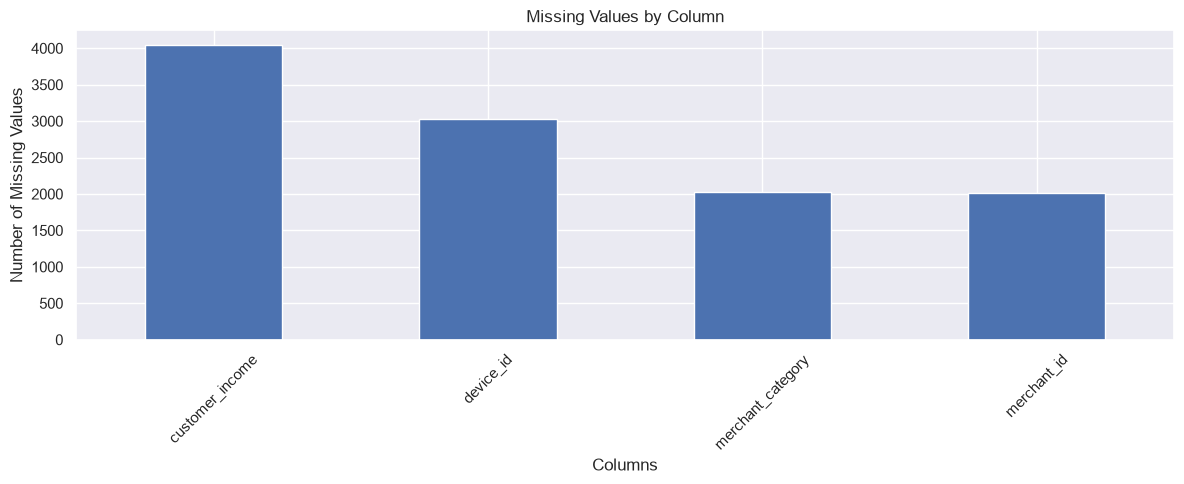

In [14]:
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_data = missing_data[missing_data > 0]

if len(missing_data) > 0:
    missing_data.plot(kind="bar", figsize=(12, 5))

    plt.title("Missing Values by Column")
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print(">> NO MISSING VALUEs FOUND..")

In [15]:
duplicate_count = df.duplicated().sum()
print(f":> DUPLICATE ROWs: {duplicate_count}")

:> DUPLICATE ROWs: 0


In [16]:
duplicate_percentage = (duplicate_count / len(df)) * 100
print(f":> DUPLICATE PERCENTAGE: {duplicate_percentage:.2f}%")

:> DUPLICATE PERCENTAGE: 0.00%


In [17]:
target_counts = df["is_fraud"].value_counts()
print(target_counts)

is_fraud
1    50506
0    50494
Name: count, dtype: int64


In [18]:
target_percentage = df["is_fraud"].value_counts(normalize=True) * 100
print(target_percentage)

is_fraud
1    50.005941
0    49.994059
Name: proportion, dtype: float64


In [19]:
target_percentage = df["is_fraud"].value_counts(normalize=True) * 100
difference = abs(target_percentage.iloc[0] - target_percentage.iloc[1])

print(f":> DIFFERENCE BETWEEN CLASSES: {difference:.2f}%")

if difference <= 10:
    print(">> DATASET APPROXIMATELY BALANCED..")
else:
    print(">> DATASET IMBALANCED..")

:> DIFFERENCE BETWEEN CLASSES: 0.01%
>> DATASET APPROXIMATELY BALANCED..


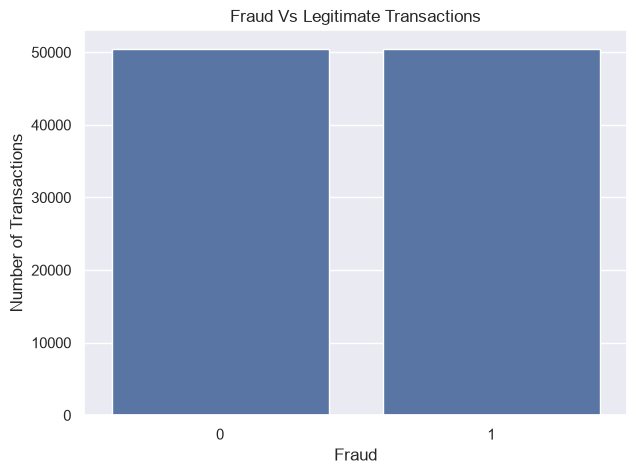

In [20]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="is_fraud")
plt.title("Fraud Vs Legitimate Transactions")
plt.xlabel("Fraud")
plt.ylabel("Number of Transactions")
plt.show()

In [21]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

print(">> NUMERICAL COLUMNs ↘")
print("-" * 25)

for column in numeric_columns:
    print("-", column)

>> NUMERICAL COLUMNs ↘
-------------------------
- customer_age
- customer_income
- account_age_days
- transaction_amount
- transactions_last_1h
- transactions_last_24h
- avg_transaction_amount_30d
- customer_transaction_count_30d
- failed_transactions_24h
- new_device_flag
- new_merchant_flag
- distance_from_home_km
- time_since_last_transaction_minutes
- merchant_risk_score
- merchant_transaction_volume
- is_fraud


In [22]:
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print(">> CATEGORICAL COLUMNs ↘")
print("-" * 25)

for column in categorical_columns:
    print("-", column)

>> CATEGORICAL COLUMNs ↘
-------------------------
- transaction_id
- customer_id
- transaction_timestamp
- customer_gender
- customer_segment
- home_country
- home_city
- currency
- payment_method
- merchant_id
- merchant_category
- device_id
- device_type
- browser
- operating_system


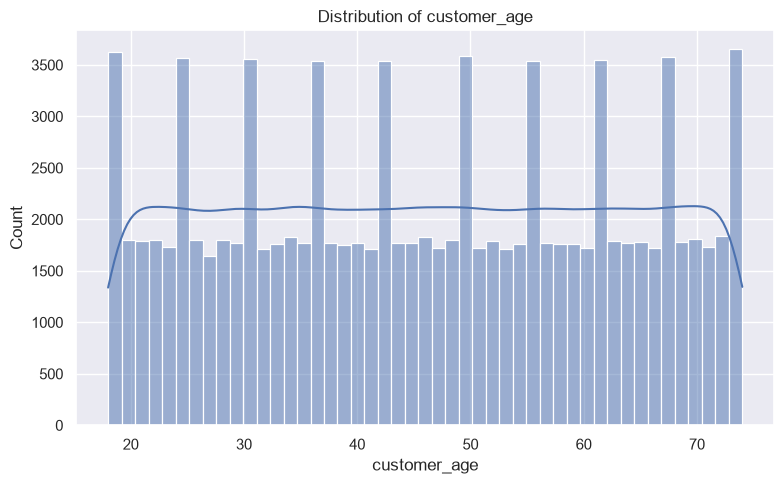

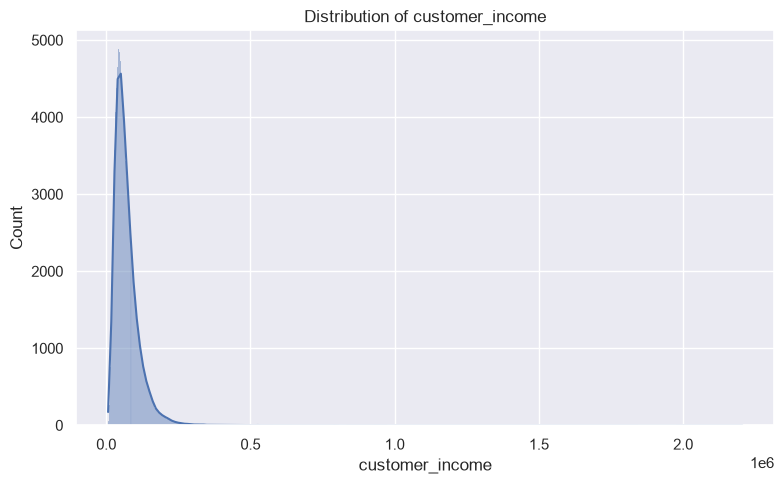

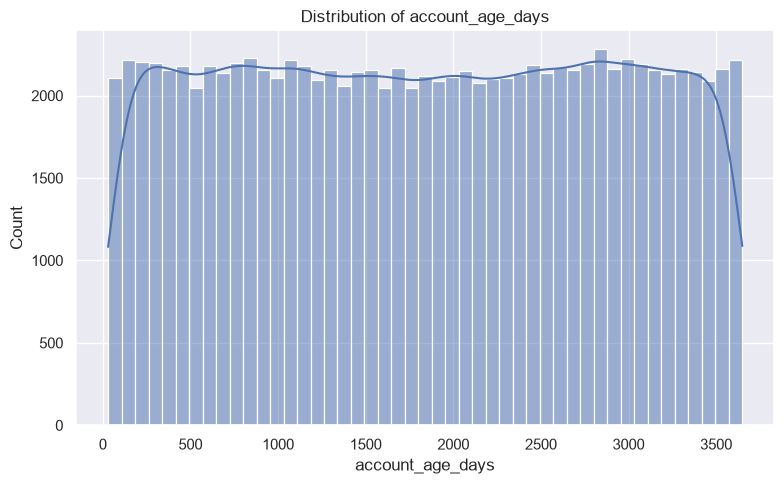

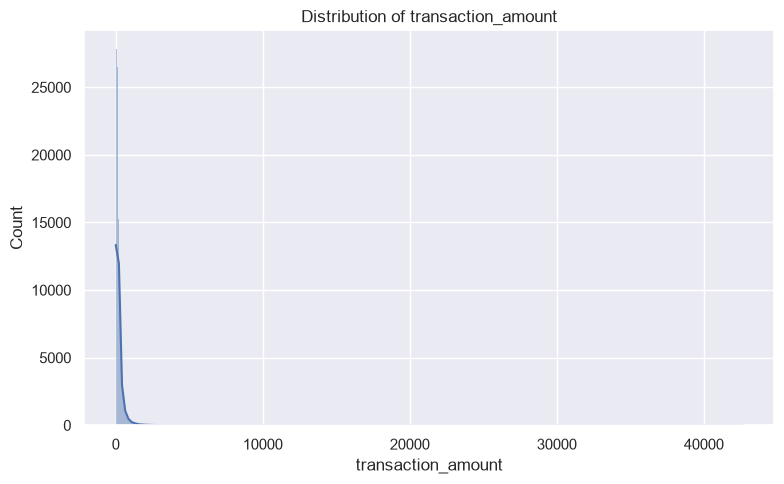

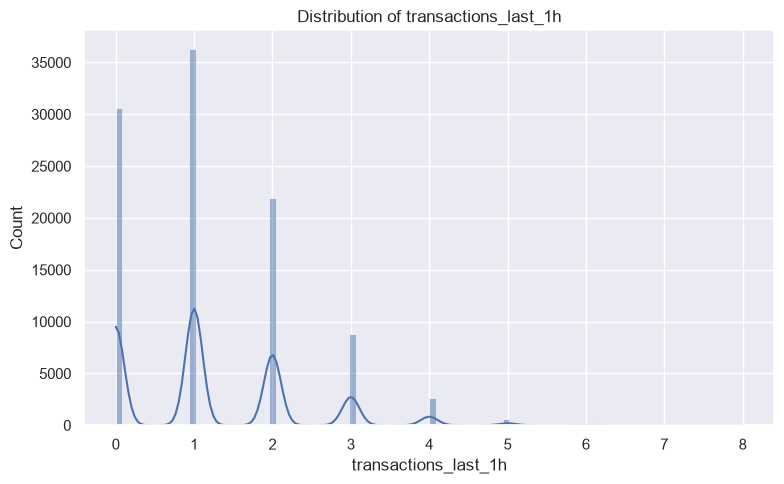

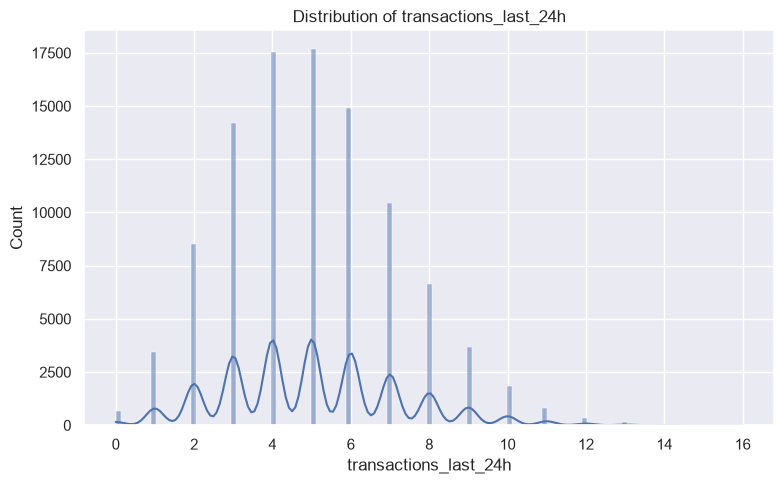

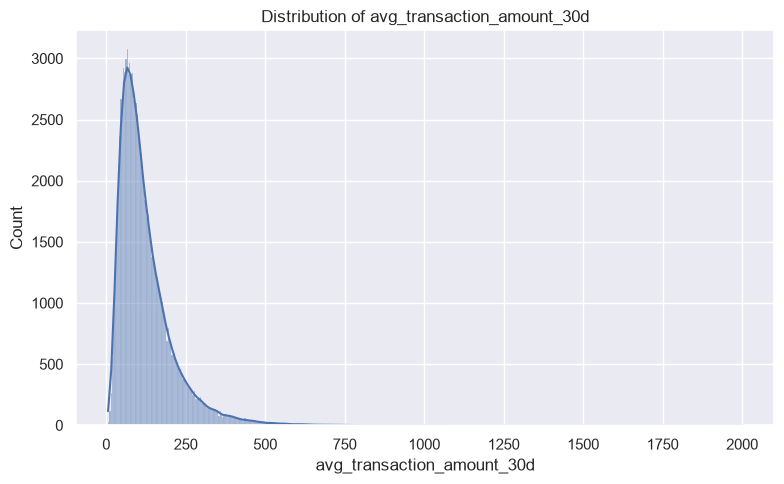

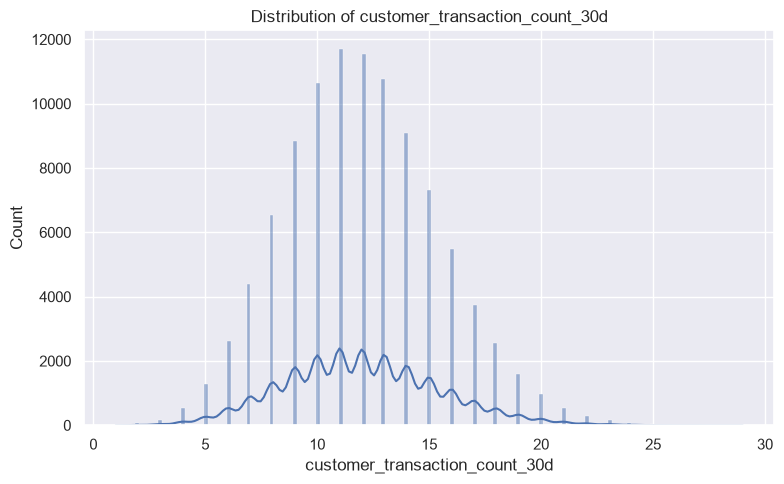

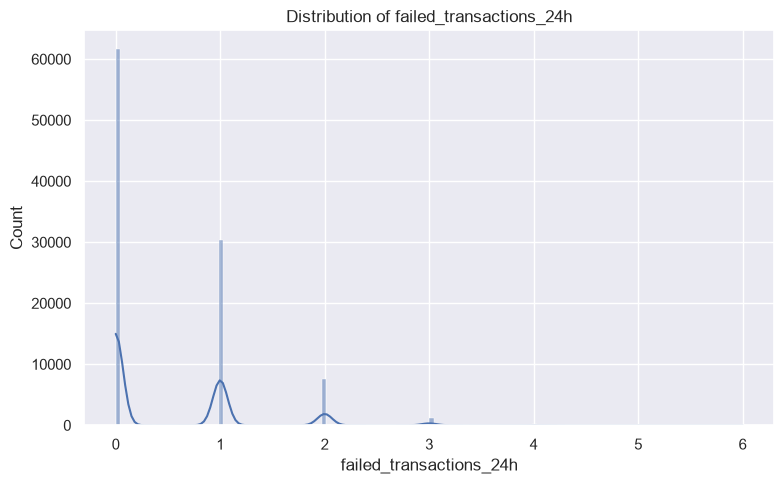

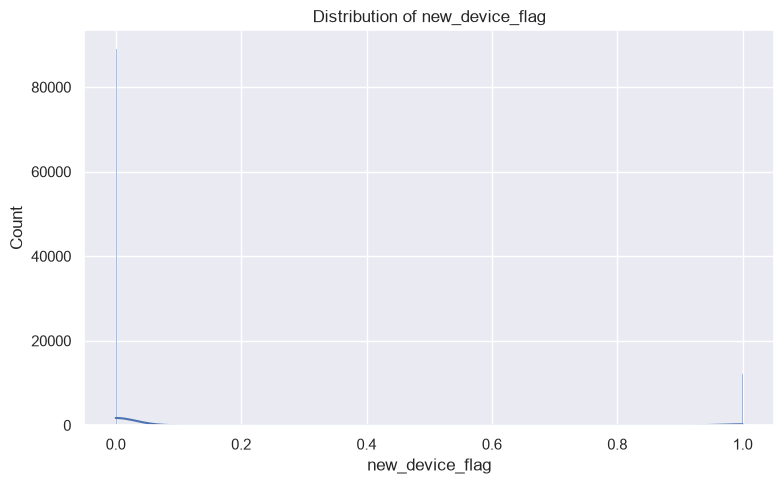

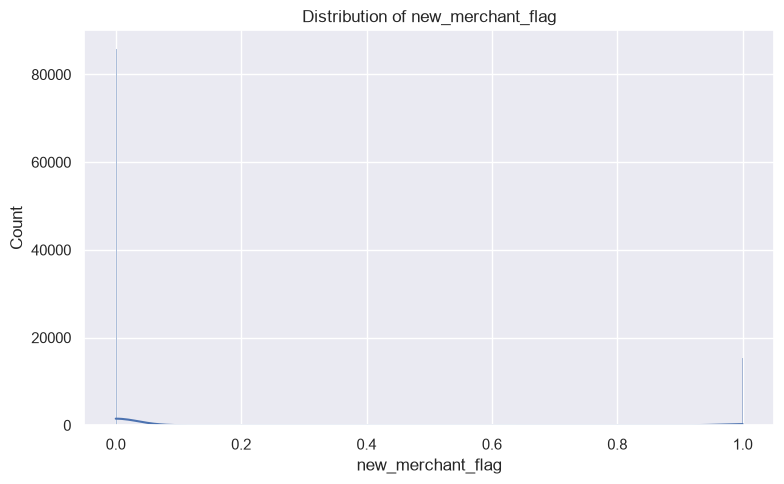

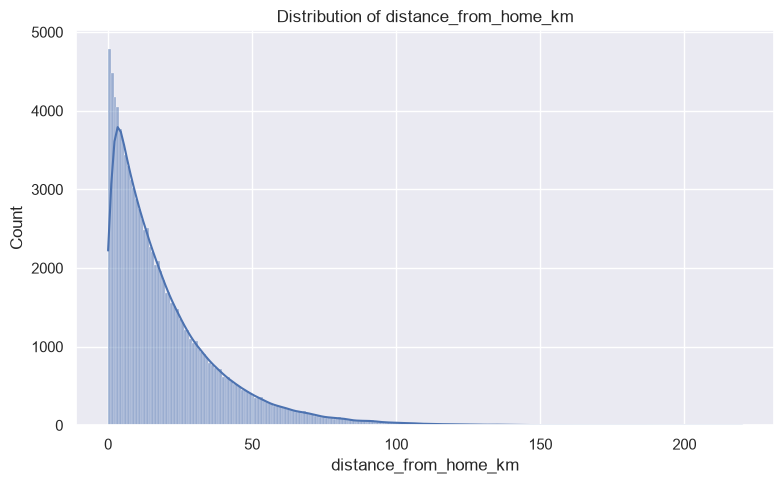

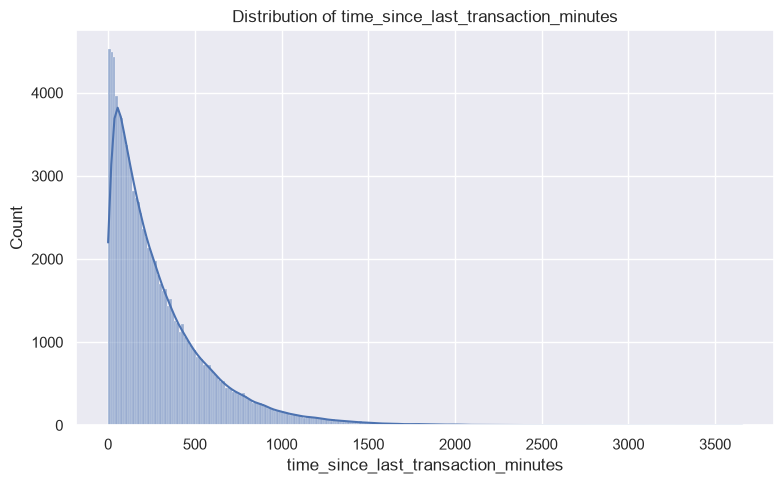

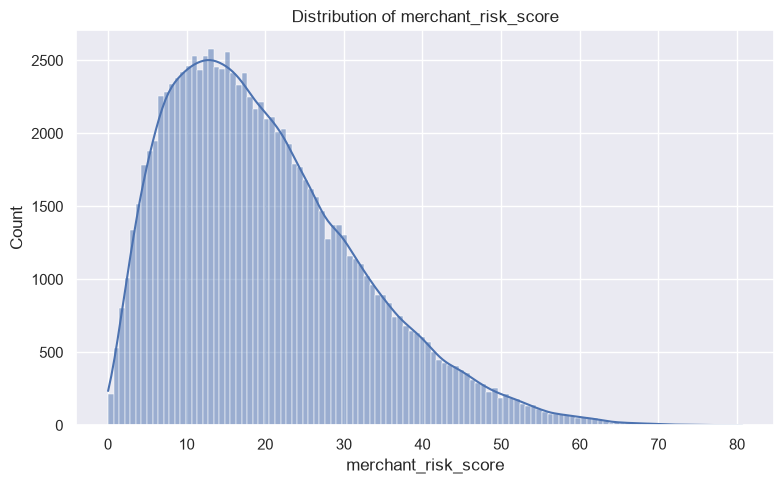

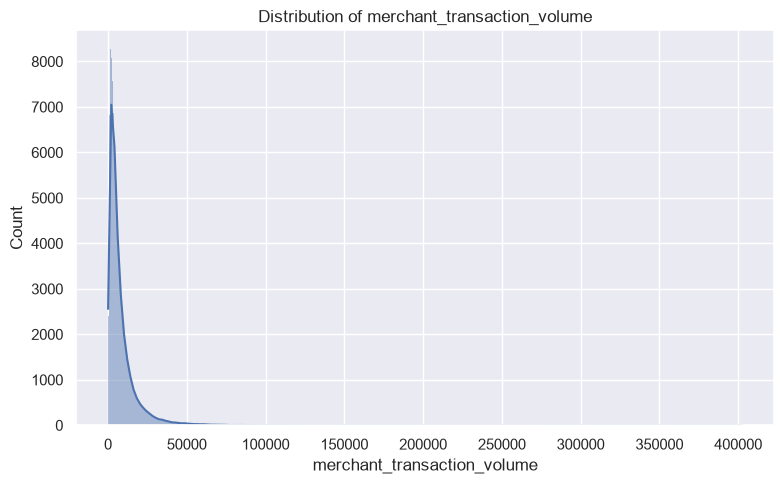

In [23]:
for column in numeric_columns:
    if column == "is_fraud":
        continue

    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=column, kde=True)
    plt.title(f"Distribution of {column}")
    plt.tight_layout()
    plt.show()

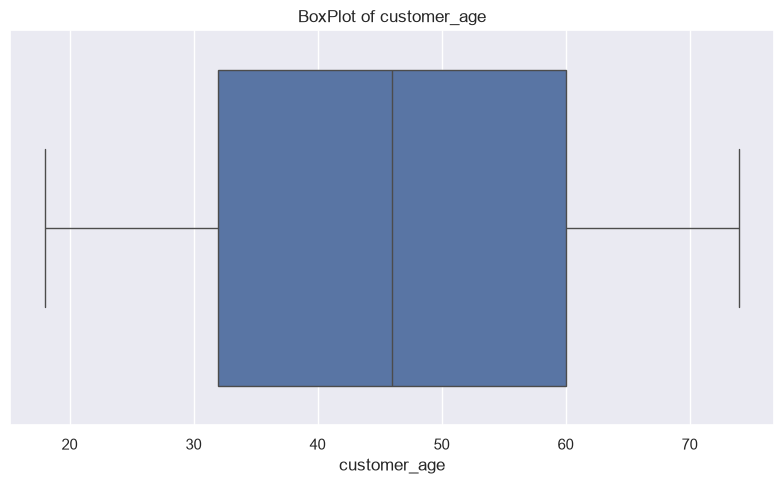

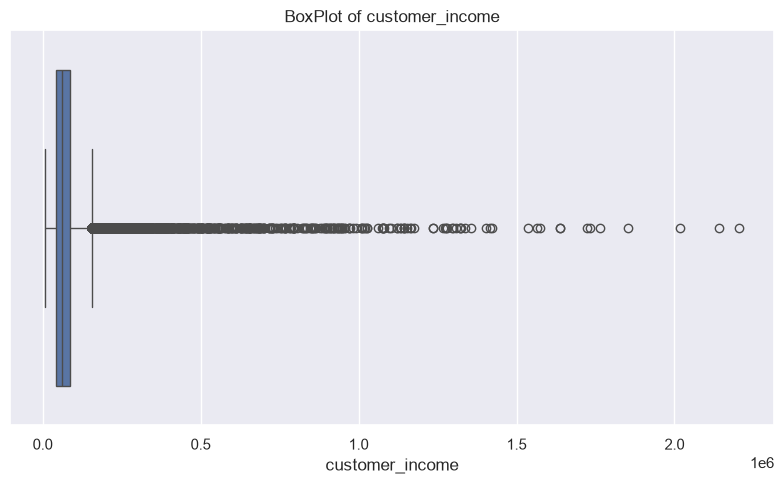

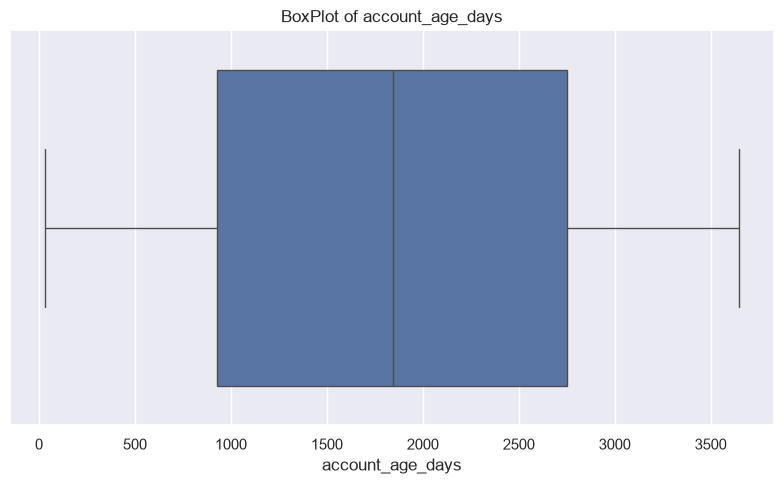

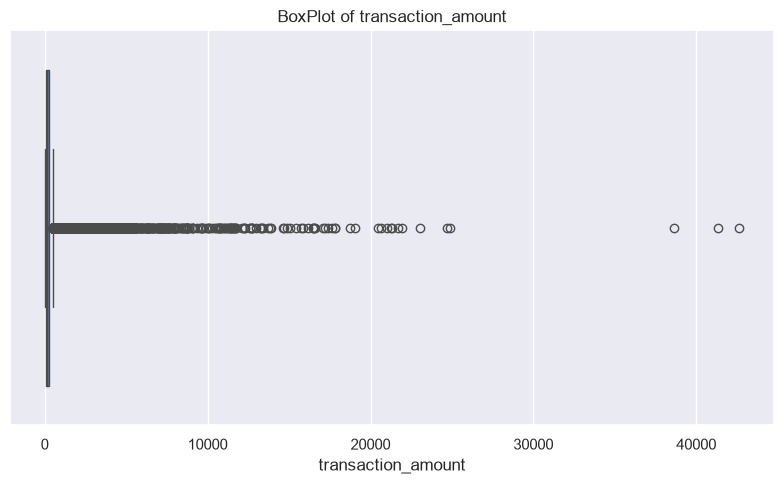

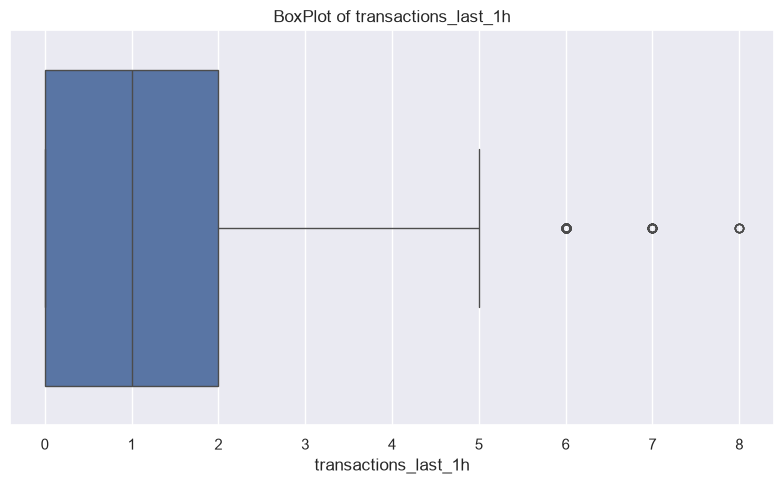

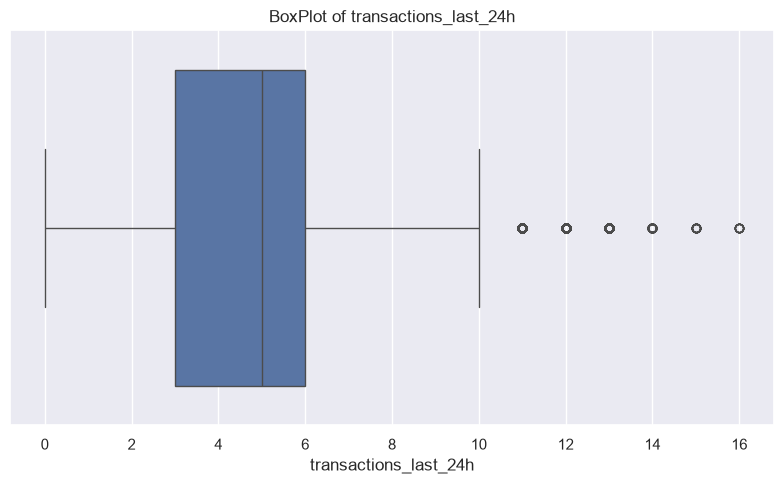

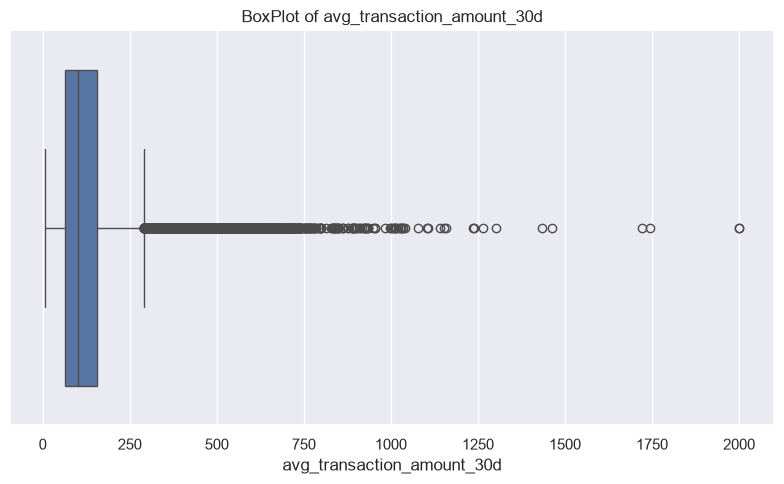

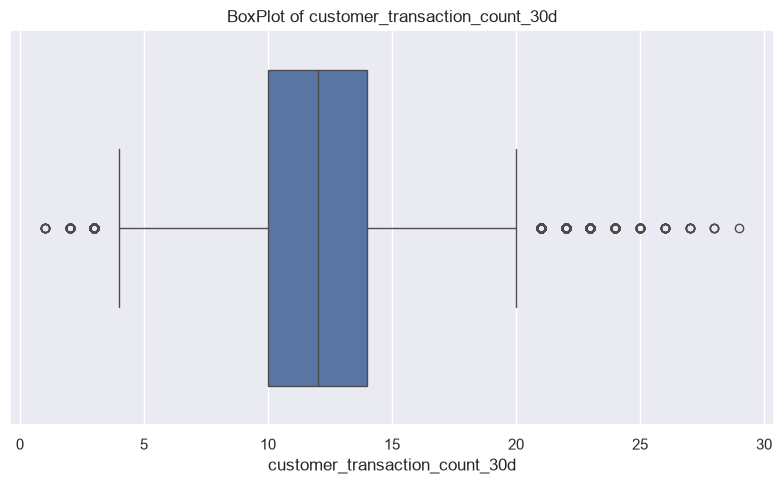

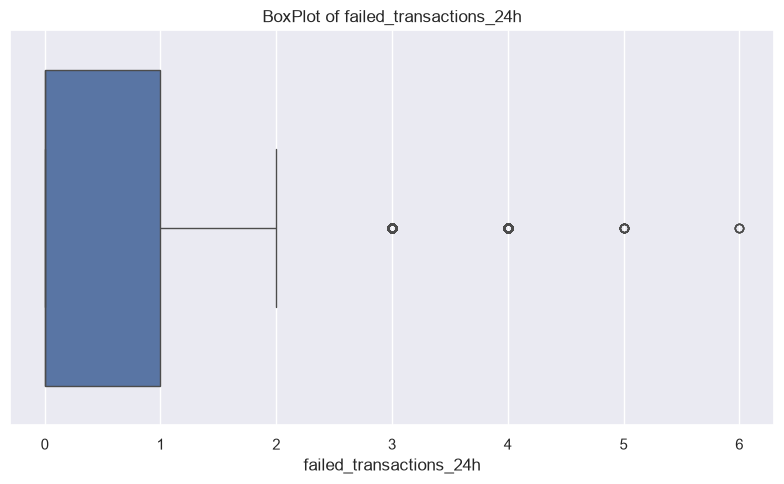

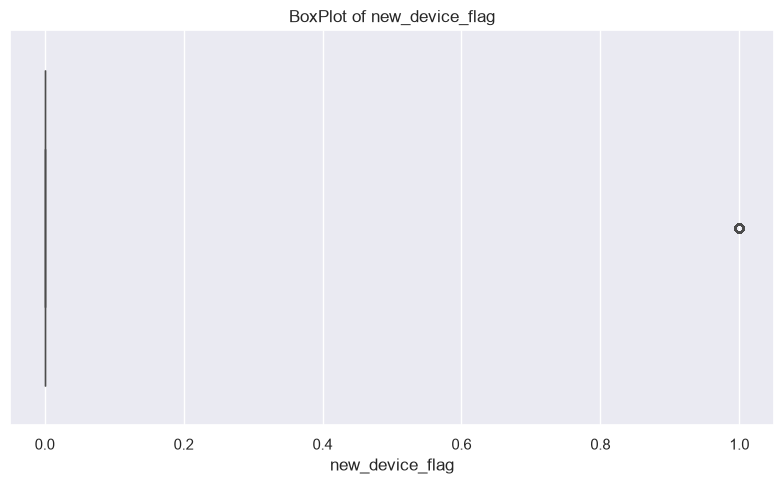

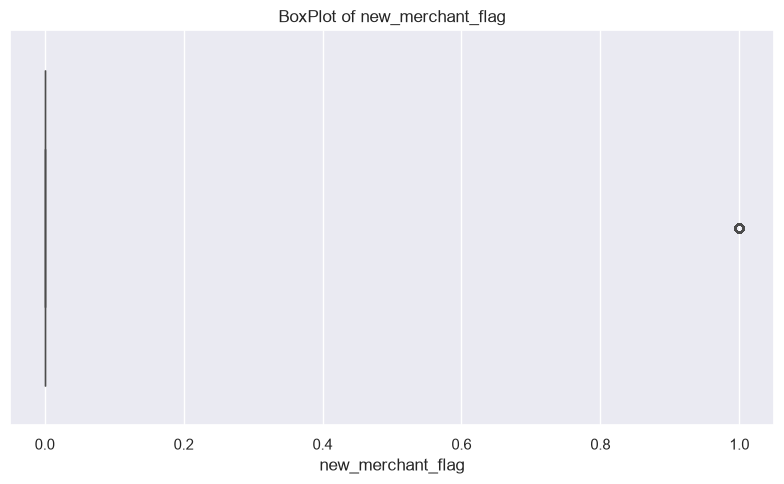

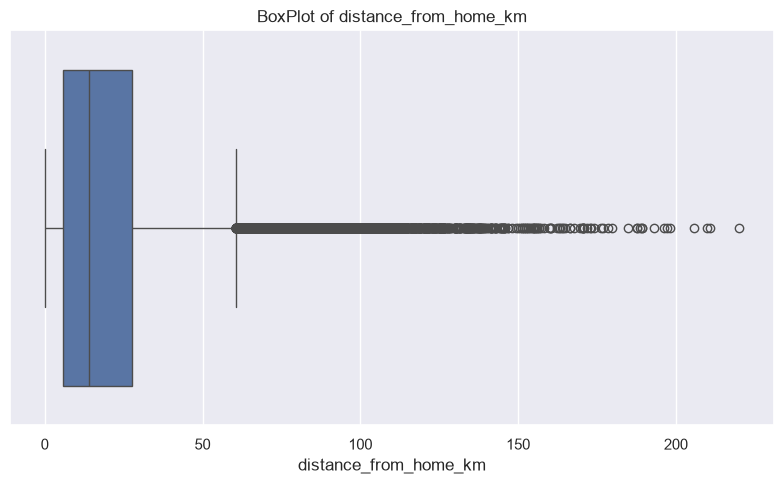

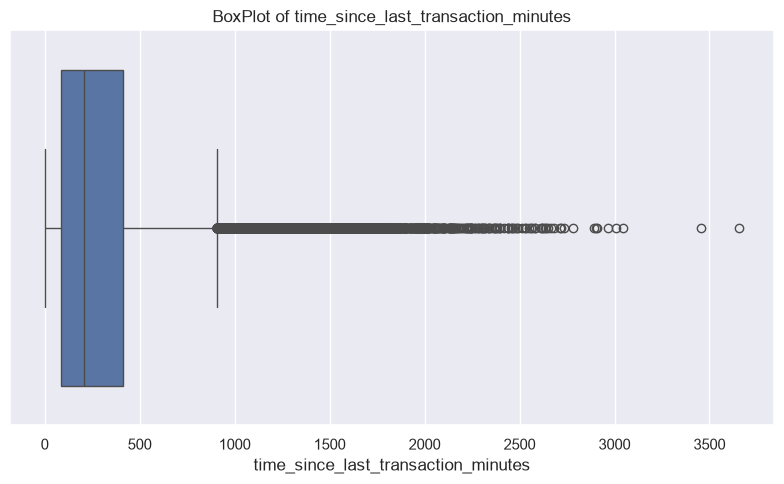

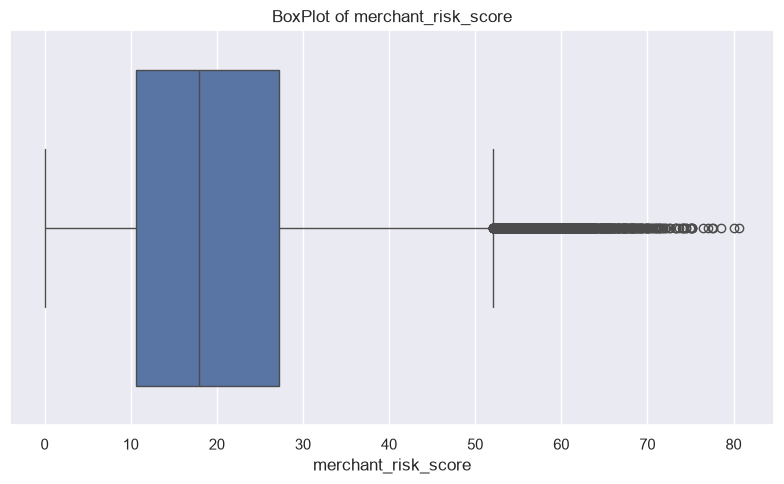

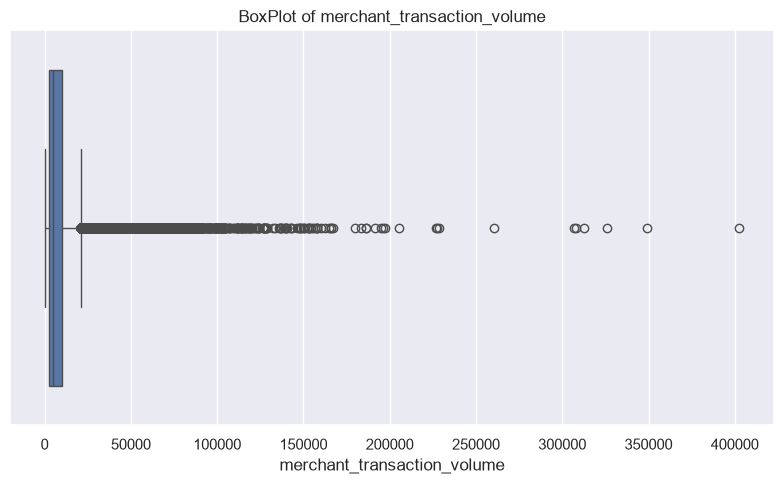

In [24]:
for column in numeric_columns:
    if column == "is_fraud":
        continue

    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=column)
    plt.title(f"BoxPlot of {column}")
    plt.tight_layout()
    plt.show()

In [25]:
for column in categorical_columns:
    if column == "is_fraud":
        continue

    print(f">> {column} ↘")
    print("-" * (len(column) + 7))
    print(df[column].value_counts().head(15), "\n")

>> transaction_id ↘
---------------------
transaction_id
TXN_0000005794    3
TXN_0000020728    3
TXN_0000047924    3
TXN_0000028630    3
TXN_0000090458    3
TXN_0000051454    3
TXN_0000099400    3
TXN_0000065295    3
TXN_0000096548    3
TXN_0000081721    3
TXN_0000038540    2
TXN_0000031011    2
TXN_0000029905    2
TXN_0000000027    2
TXN_0000035514    2
Name: count, dtype: int64 

>> customer_id ↘
------------------
customer_id
CUST_00008987    13
CUST_00013731    12
CUST_00016923    12
CUST_00007372    12
CUST_00005384    12
CUST_00028949    12
CUST_00017997    11
CUST_00025888    11
CUST_00022505    11
CUST_00019954    11
CUST_00027302    11
CUST_00026081    11
CUST_00002567    11
CUST_00002710    11
CUST_00030766    11
Name: count, dtype: int64 

>> transaction_timestamp ↘
----------------------------
transaction_timestamp
2023-04-21 02:05:48    2
2023-08-21 01:04:12    2
2025-07-02 04:48:33    2
2024-11-20 15:20:45    2
2024-09-16 09:34:16    2
2025-08-23 23:19:23    2
2024-09-10 

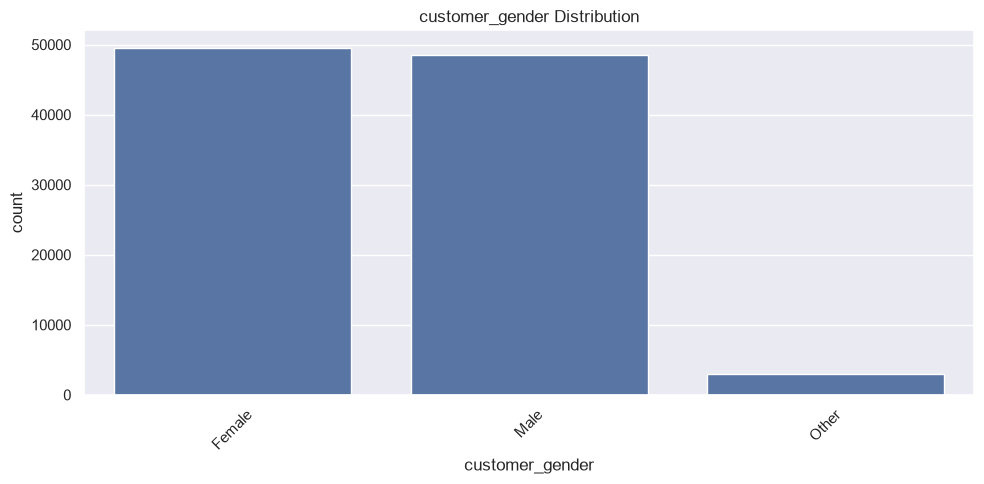

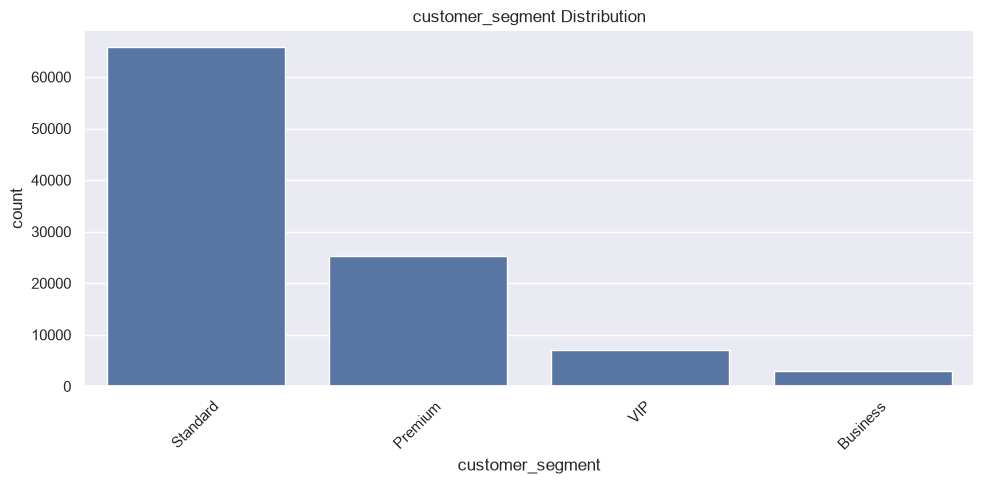

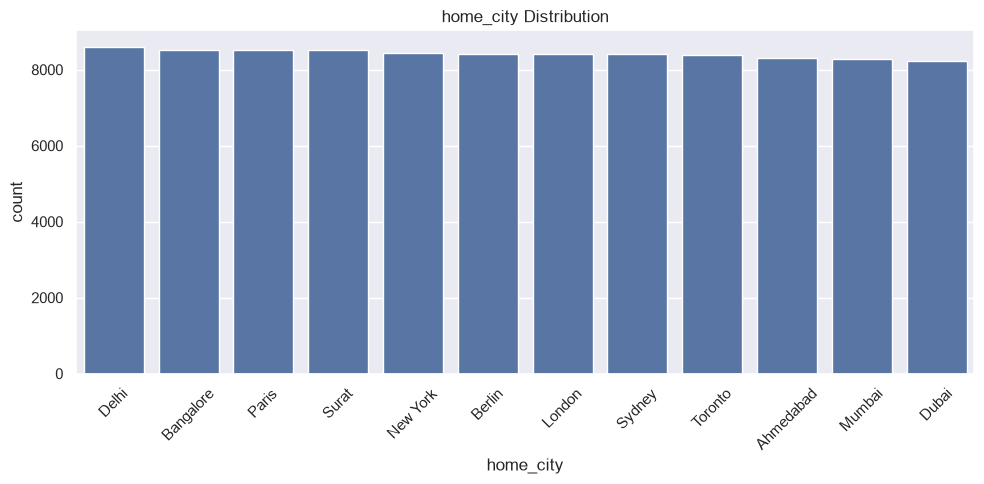

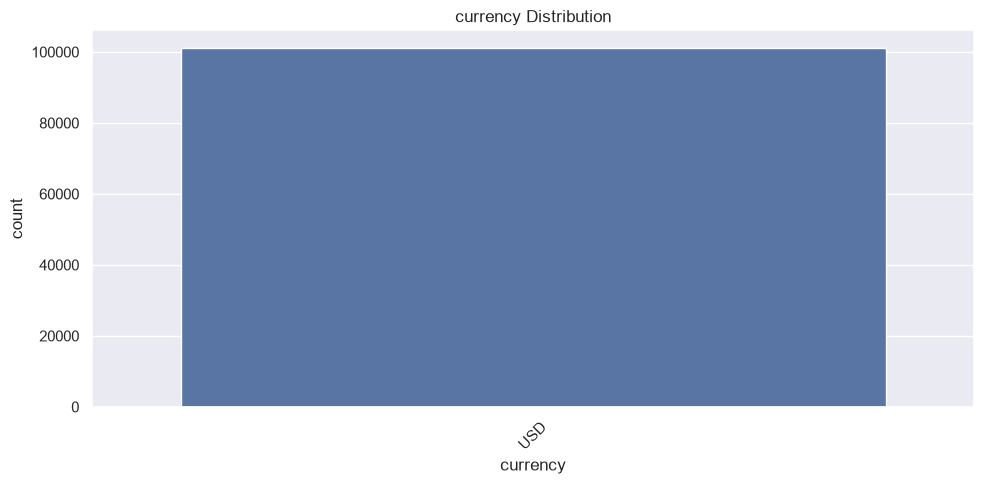

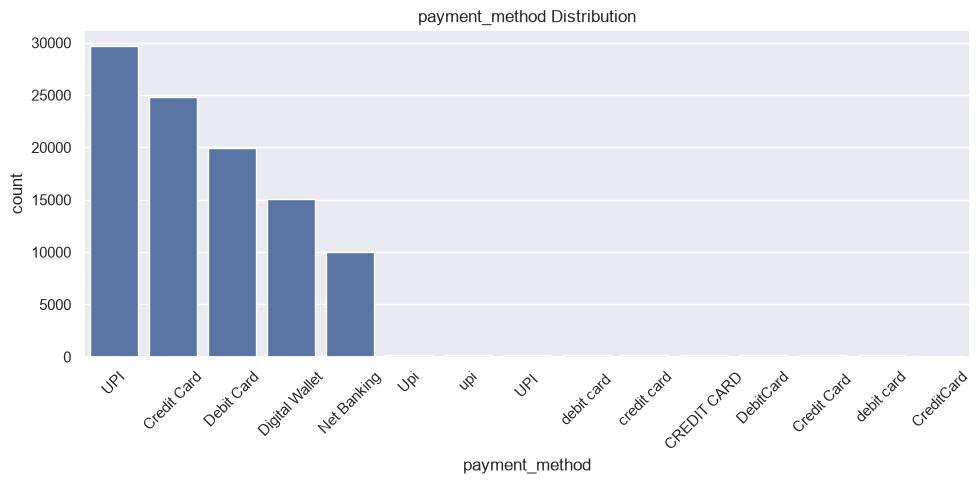

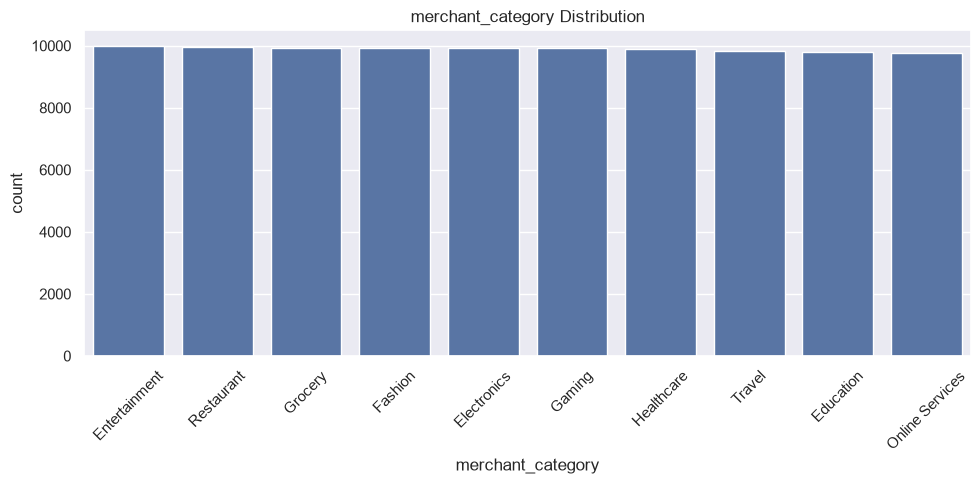

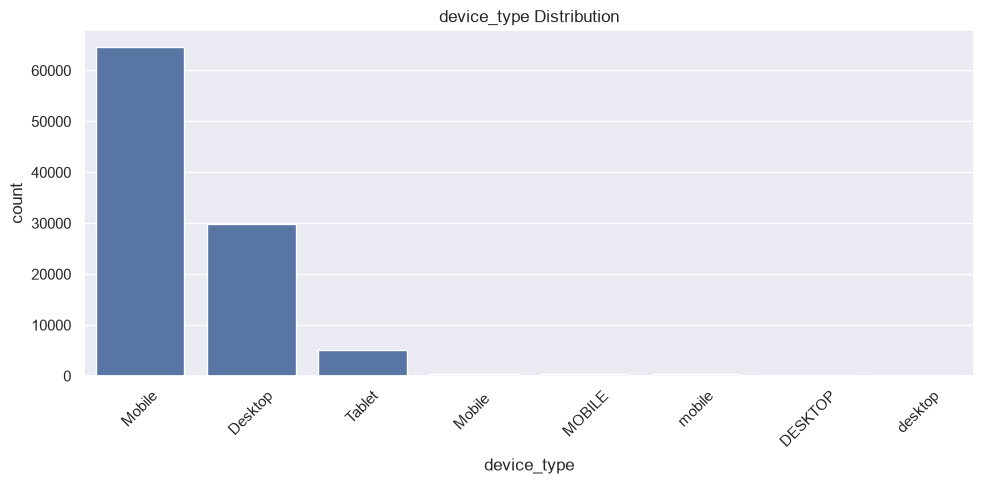

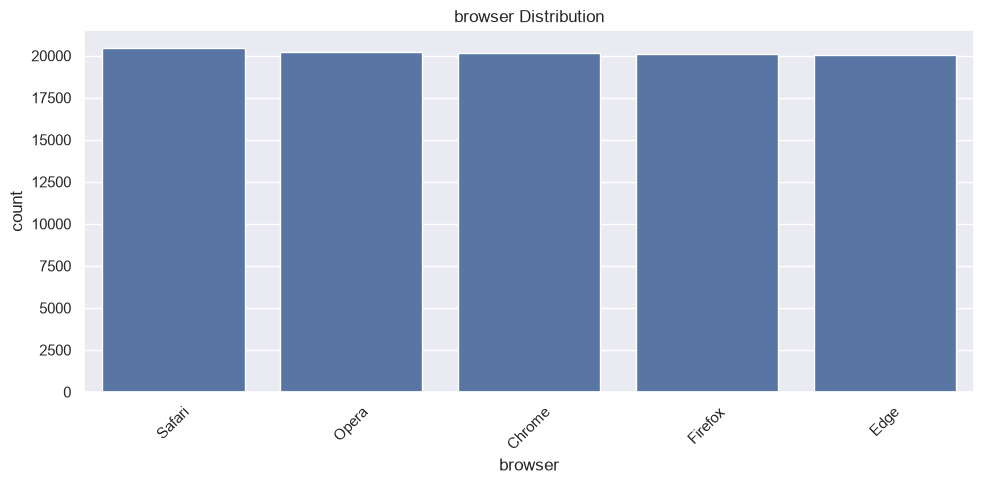

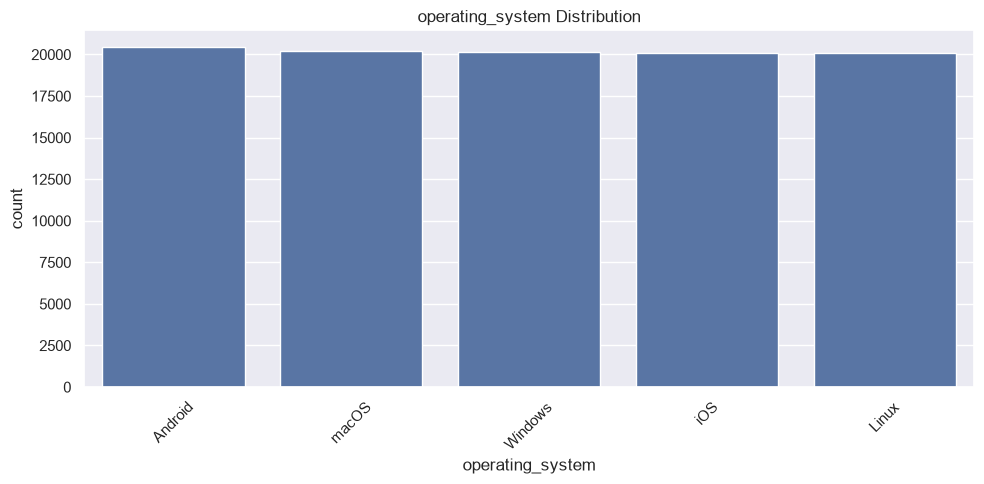

In [26]:
for column in categorical_columns:
    if column == "is_fraud":
        continue

    if df[column].nunique() <= 15:
        plt.figure(figsize=(10, 5))
        sns.countplot(data=df, x=column, order=df[column].value_counts().index)
        plt.title(f"{column} Distribution")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

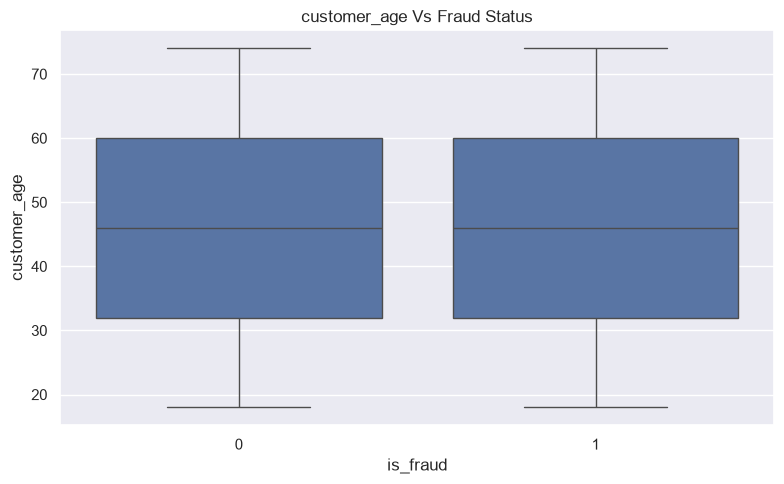

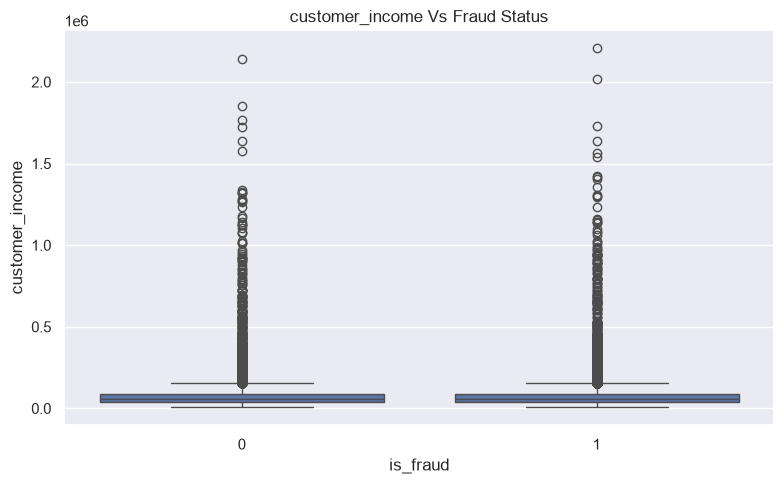

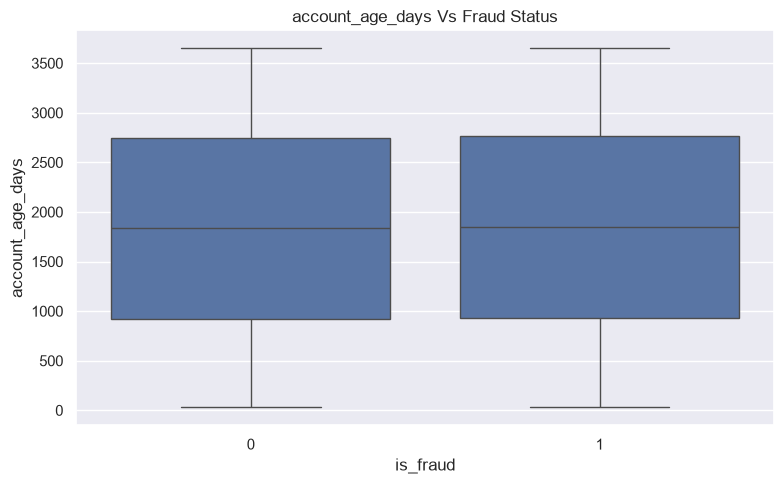

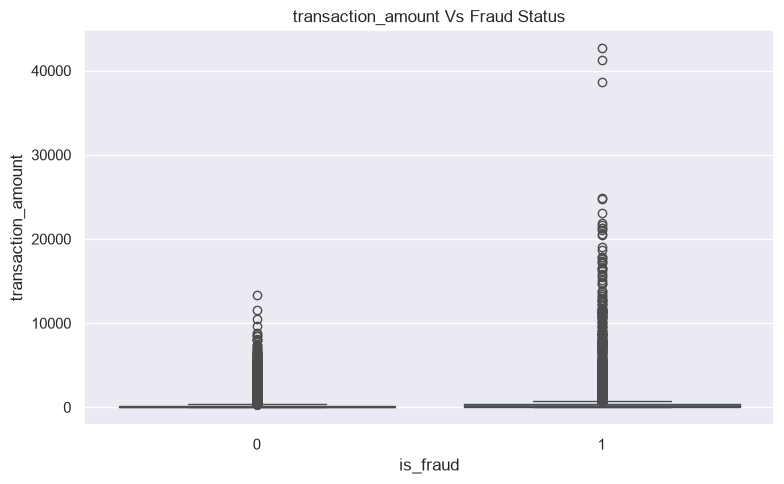

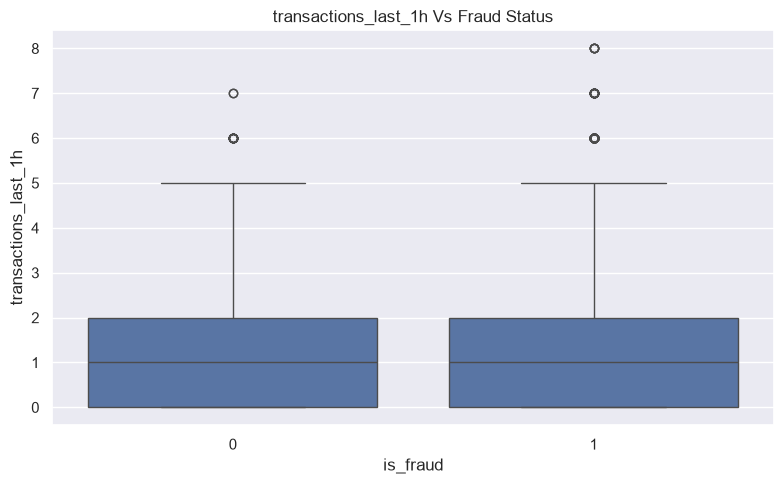

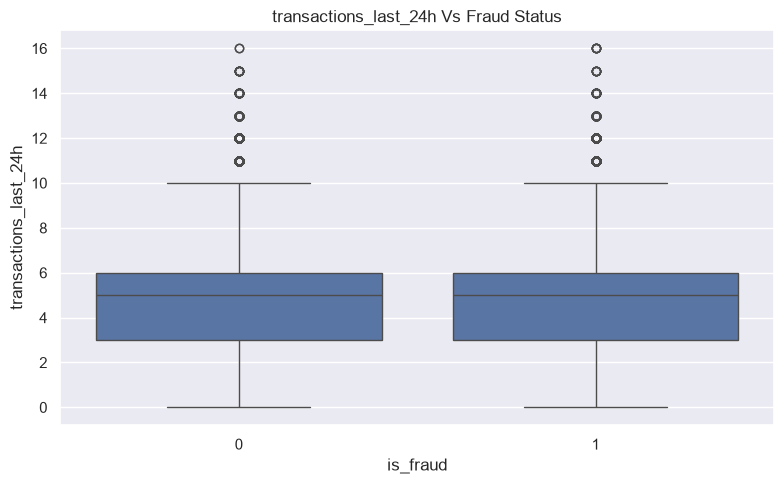

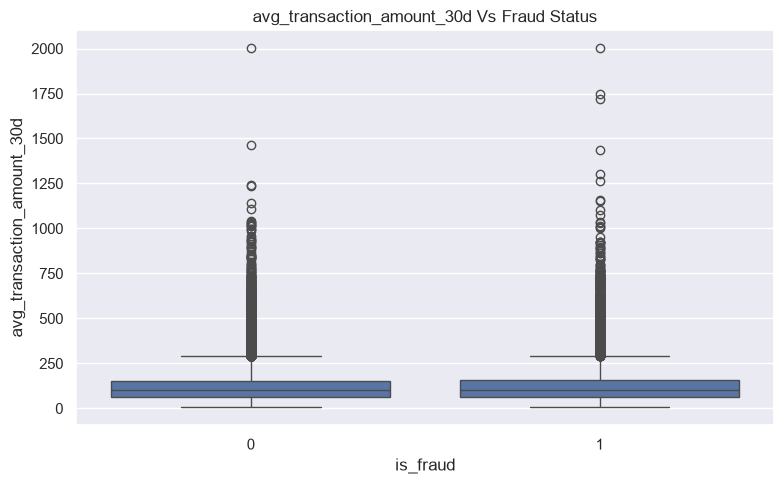

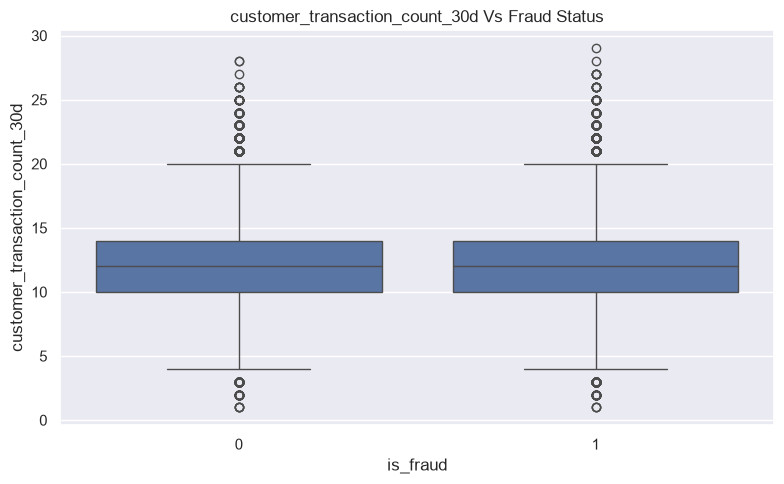

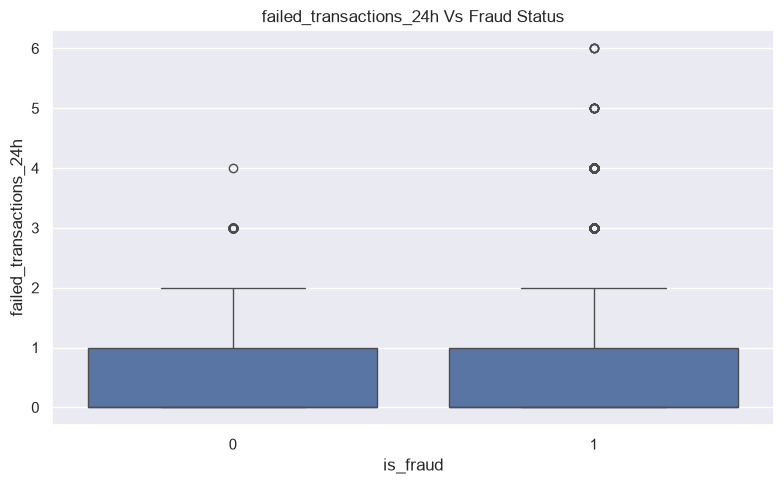

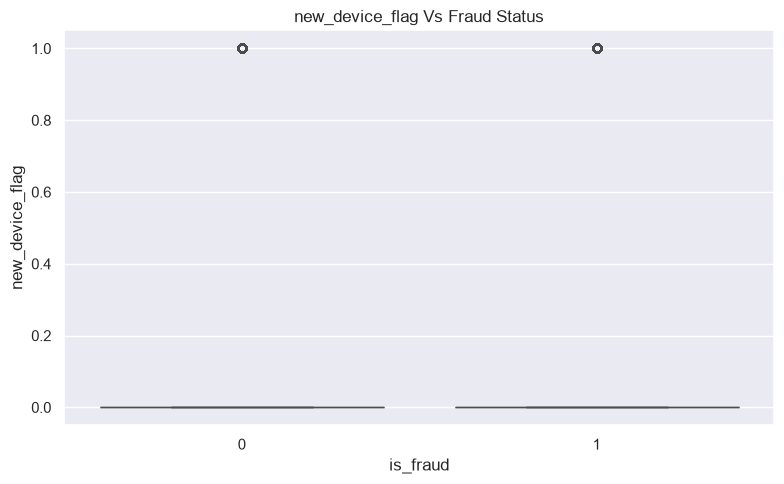

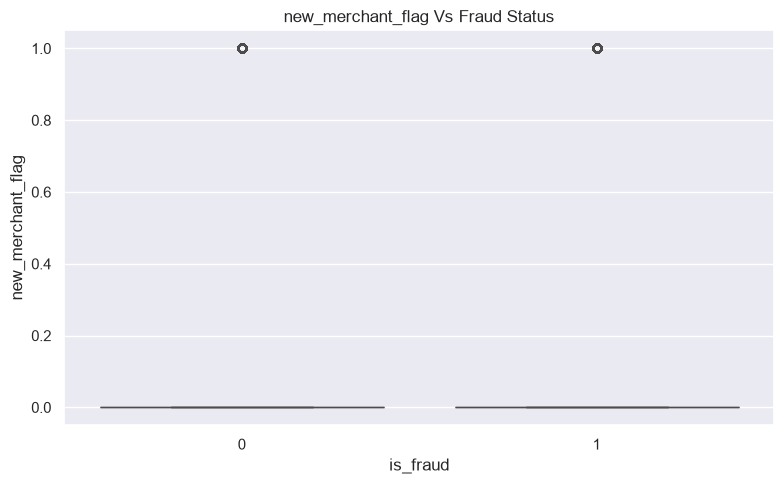

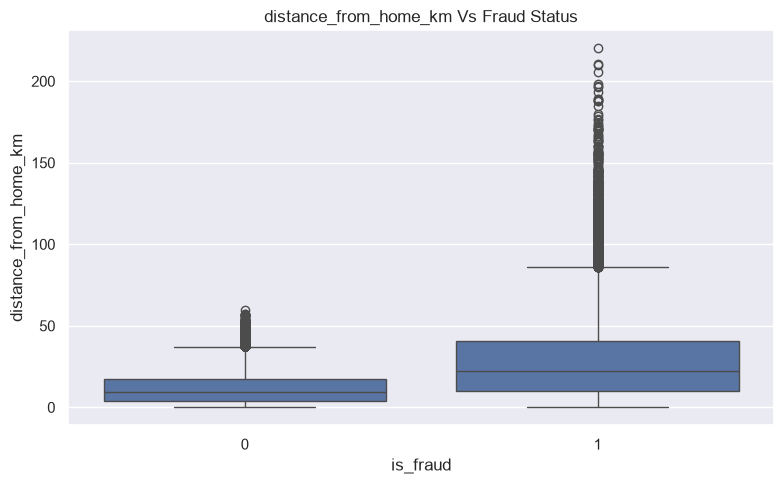

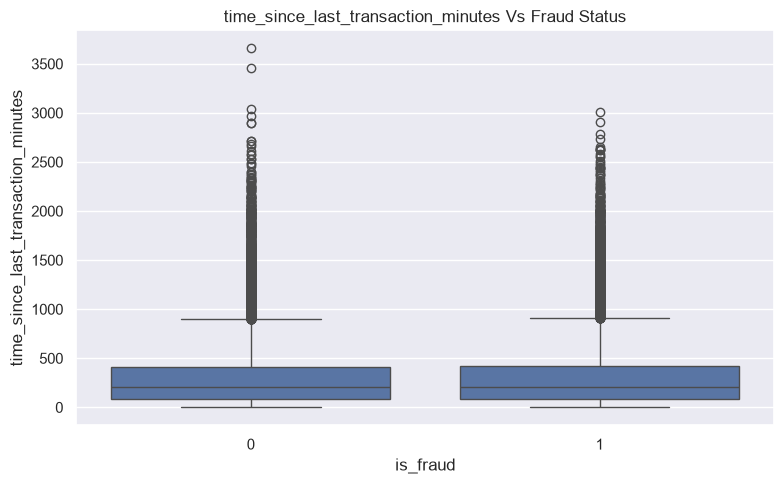

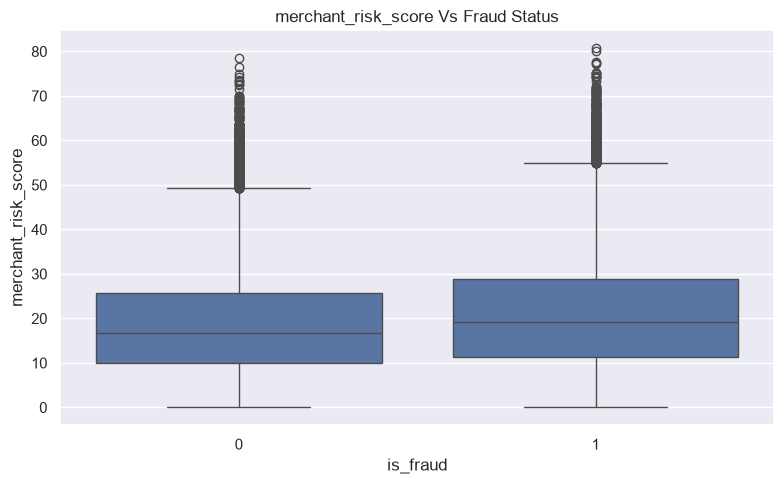

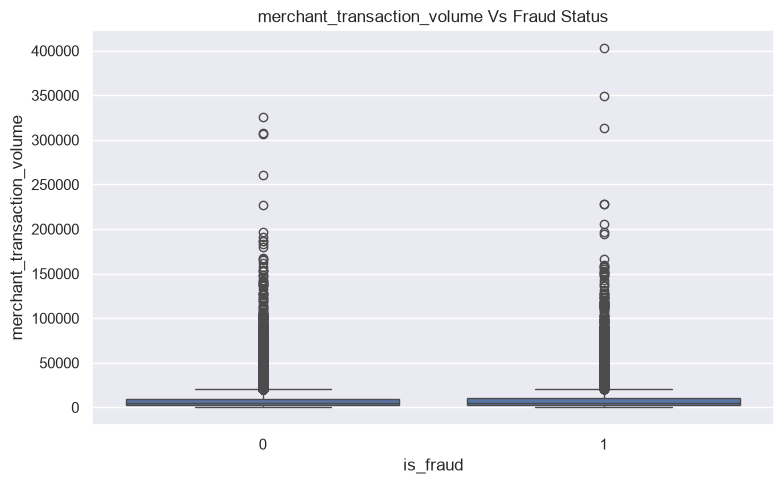

In [27]:
for column in numeric_columns:
    if column == "is_fraud":
        continue

    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="is_fraud", y=column)
    plt.title(f"{column} Vs Fraud Status")
    plt.tight_layout()
    plt.show()

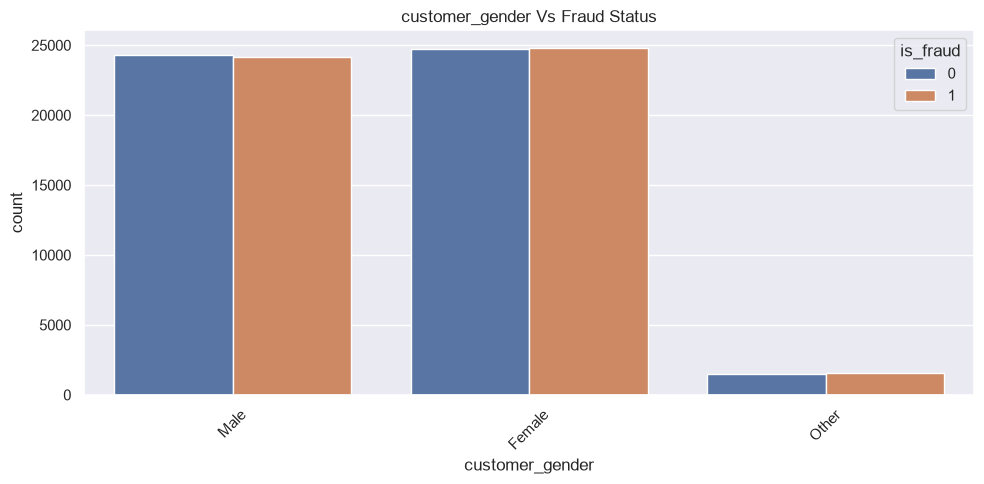

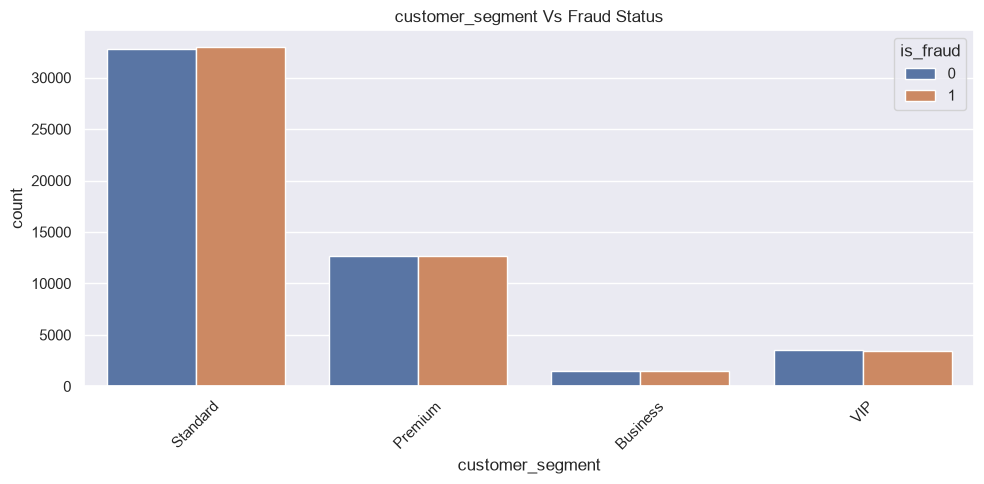

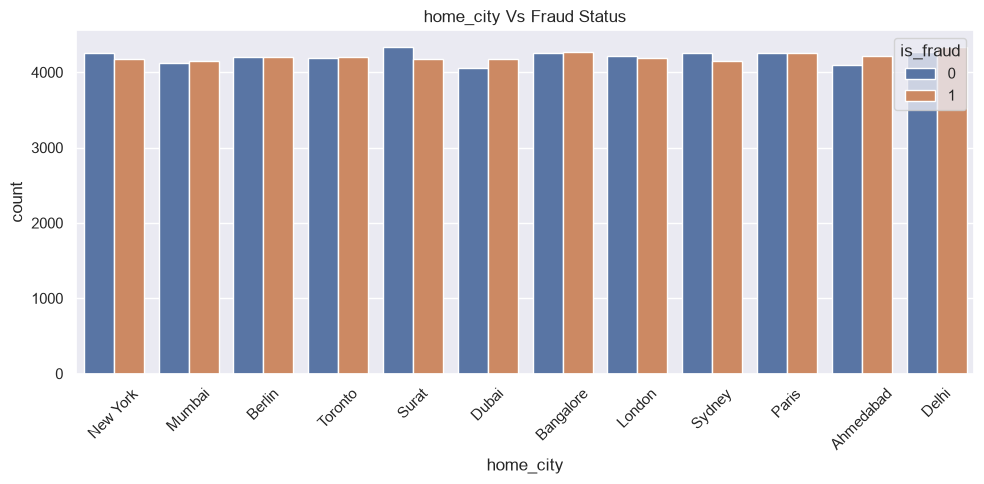

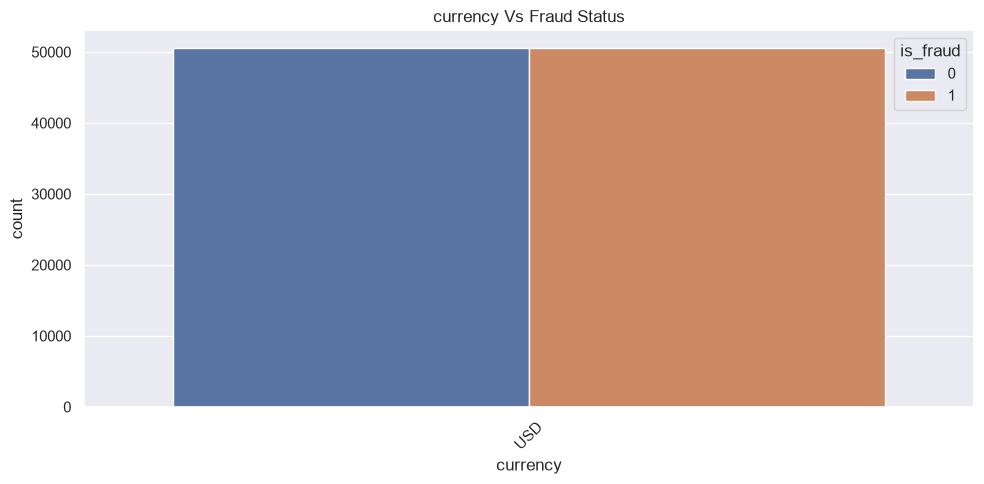

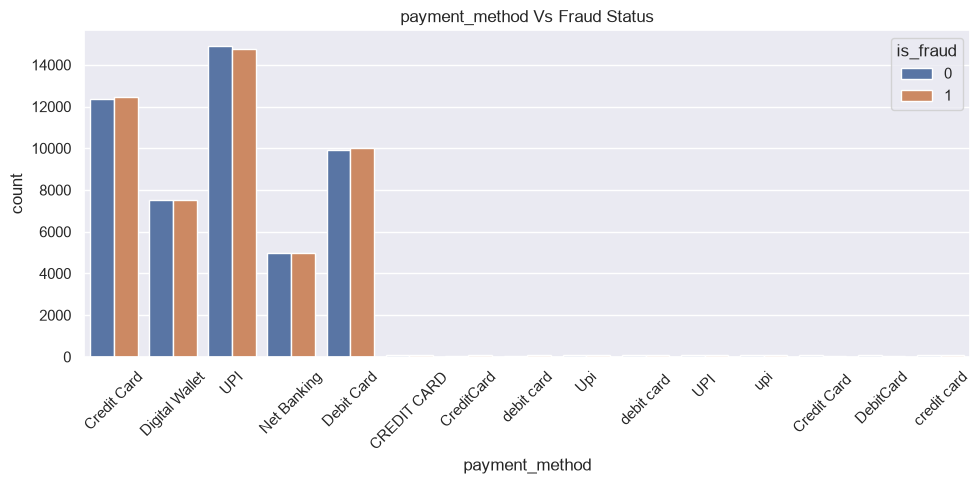

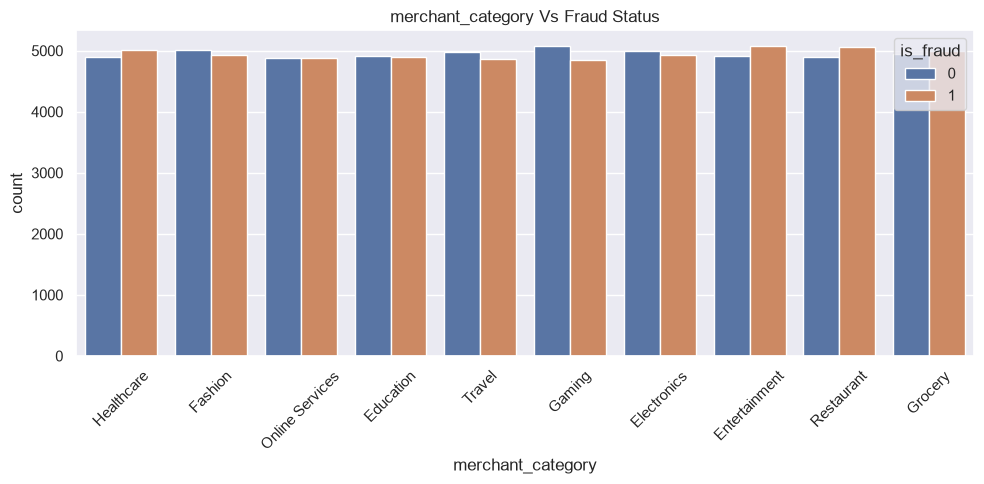

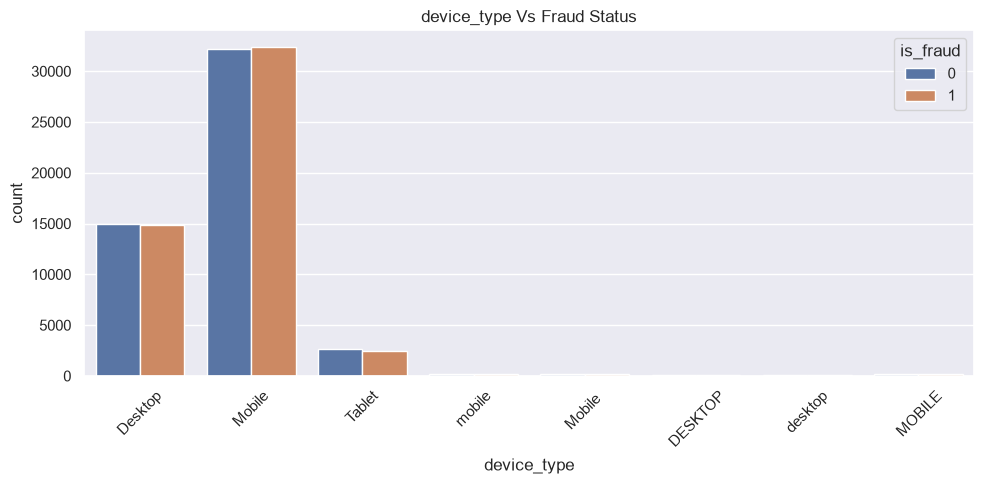

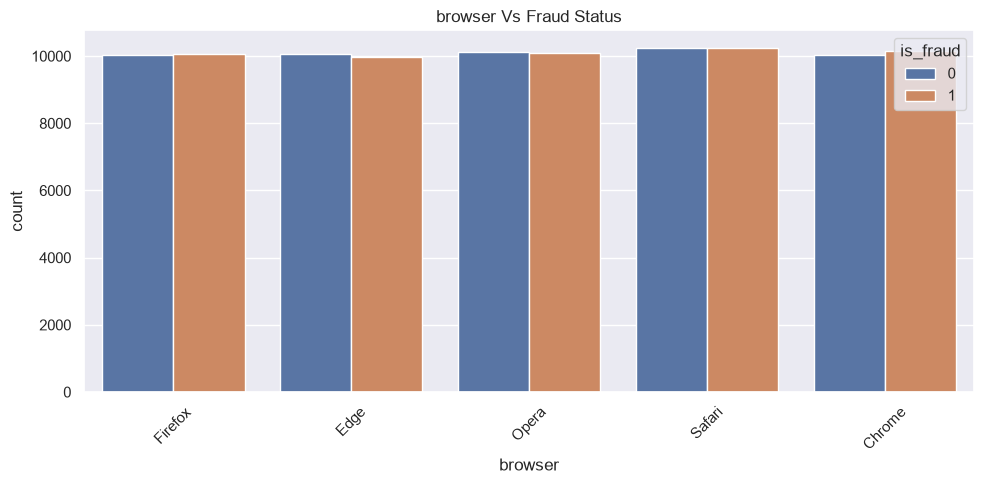

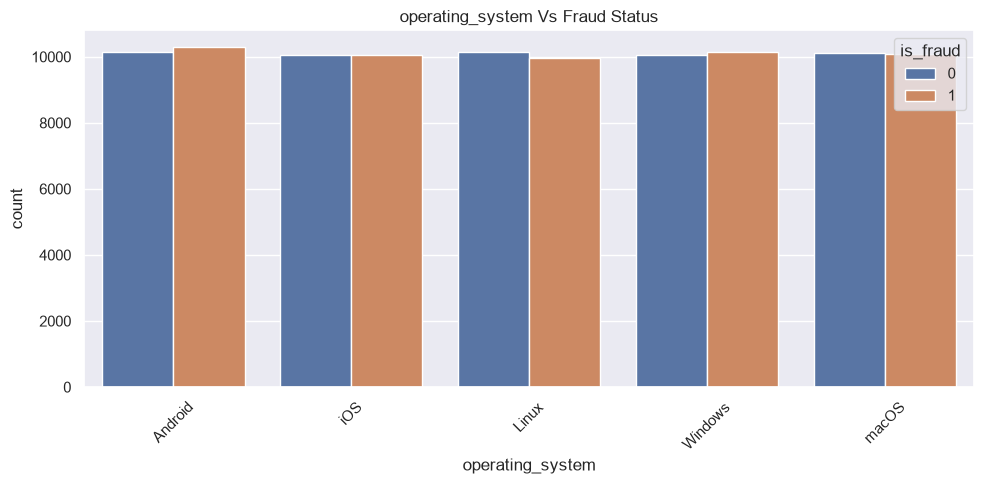

In [28]:
for column in categorical_columns:
    if column == "is_fraud":
        continue

    if df[column].nunique() <= 15:
        plt.figure(figsize=(10, 5))
        sns.countplot(data=df, x=column, hue="is_fraud")
        plt.title(f"{column} Vs Fraud Status")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

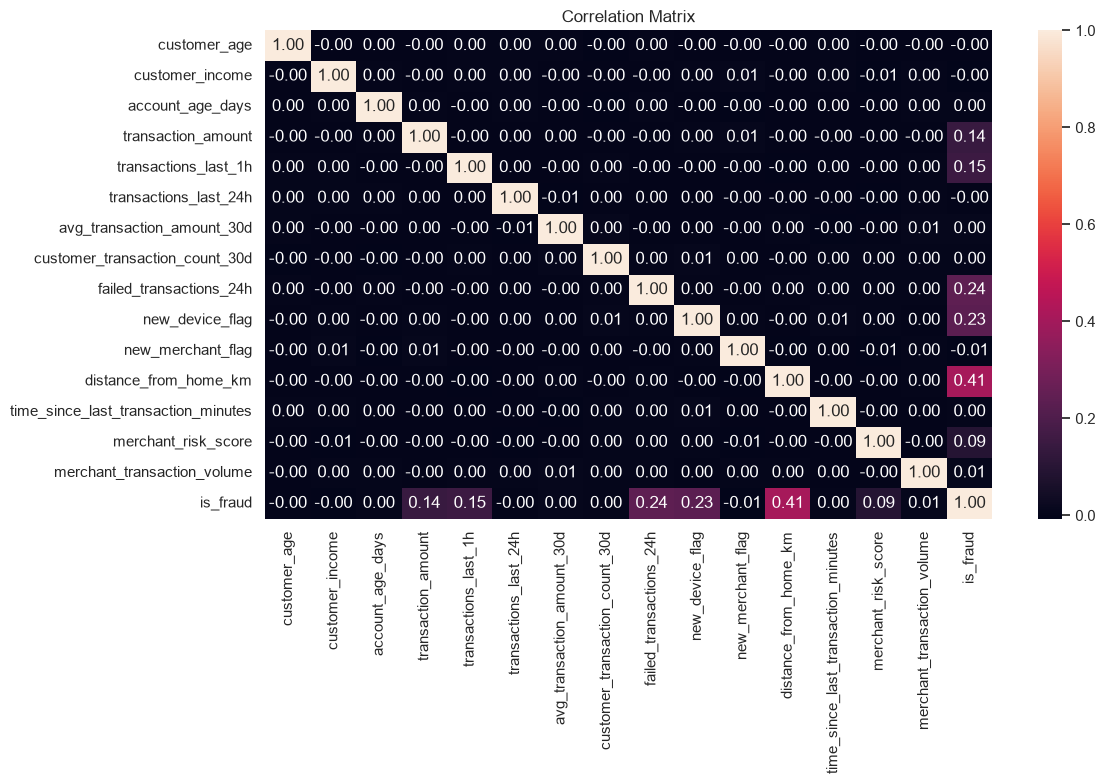

In [29]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [30]:
fraud_correlation = correlation["is_fraud"].sort_values(ascending=False)
print(fraud_correlation)

is_fraud                               1.000000
distance_from_home_km                  0.409580
failed_transactions_24h                0.238516
new_device_flag                        0.230784
transactions_last_1h                   0.152697
transaction_amount                     0.142596
merchant_risk_score                    0.092587
merchant_transaction_volume            0.005585
avg_transaction_amount_30d             0.004832
account_age_days                       0.003903
time_since_last_transaction_minutes    0.002582
customer_transaction_count_30d         0.001491
transactions_last_24h                 -0.000596
customer_age                          -0.003214
customer_income                       -0.003529
new_merchant_flag                     -0.006217
Name: is_fraud, dtype: float64


In [31]:
correlation_paris = (
    correlation.where(np.triu(np.ones(correlation.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
print(correlation_paris.head(20))

distance_from_home_km           is_fraud                               0.409580
failed_transactions_24h         is_fraud                               0.238516
new_device_flag                 is_fraud                               0.230784
transactions_last_1h            is_fraud                               0.152697
transaction_amount              is_fraud                               0.142596
merchant_risk_score             is_fraud                               0.092587
avg_transaction_amount_30d      merchant_transaction_volume            0.007499
new_device_flag                 time_since_last_transaction_minutes    0.007012
transaction_amount              new_merchant_flag                      0.006238
merchant_transaction_volume     is_fraud                               0.005585
customer_transaction_count_30d  new_device_flag                        0.005422
customer_income                 new_merchant_flag                      0.005028
avg_transaction_amount_30d      is_fraud

In [32]:
unique_values = df.nunique().sort_values(ascending=False)
print(unique_values)

transaction_timestamp                  100944
transaction_id                          99508
device_id                               88196
customer_income                         65532
time_since_last_transaction_minutes     53645
merchant_id                             42945
transaction_amount                      41390
customer_id                             31688
avg_transaction_amount_30d              27944
merchant_transaction_volume             24501
distance_from_home_km                    8983
merchant_risk_score                      6086
account_age_days                         3620
customer_age                               57
customer_transaction_count_30d             29
home_country                               17
transactions_last_24h                      17
payment_method                             15
home_city                                  12
merchant_category                          10
transactions_last_1h                        9
device_type                       

# EDA Summary

## Dataset

The dataset contains transaction-level information for fraud detection.

## Target
The target column is `is_fraud`.

- 0 = Legitimate transaction
- 1 = Fraudulent transaction

The target classes are approximately balanced.

## Data Quality
The dataset was inspected for:
- Missing values
- Duplicate records
- Data types
- Numerical outliers
- Categorical inconsistencies

## Feature Analysis
Numerical and categorical features were analyzed individually and against the fraud target.

## Correlation
Correlation analysis was performed on numerical features to understand relationships between variables.